1. Generate wavefront
   - fixed low-order aberration
   - random atmospheric phase screen

2. Measure wavefront slopes
   - geometric Shack-Hartmann model

3. Reconstruct wavefront
   - response matrix
   - least-squares modal reconstruction

4. Analyze limitations
   - noise sensitivity
   - lenslet sampling
   - modal truncation / fitting error

5. Demonstrate low-order AO correction
   - before/after residual RMS
   - optional PSF and Strehl ratio

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

import zernike
import phase_screen
import reconstruction

importlib.reload(zernike)
importlib.reload(phase_screen)
importlib.reload(reconstruction)

from zernike import (
    make_pupil_grid,
    zernike_named_modes,
    synthesize_wavefront,
)

from phase_screen import fourier_phase_screen

from reconstruction import (
    build_response_matrix,
    measure_slopes,
    reconstruct_wavefront,
    residual_wavefront,
    rms,
)

import shwfs_detector
importlib.reload(shwfs_detector)

from shwfs_detector import (
    build_detector_response_matrix,
    measure_centroid_shifts,
    reconstruct_from_centroid_shifts,
)

from reconstruction import (
    synthesize_from_coefficients,
)

/var/folders/v4/pystxgv15lvgmlg1zg85s3xm0000gn/T/ipykernel_89046/794160998.py:5: DeprecationWarning: Importing the root-level module 'zernike' is deprecated (scheduled for release 0.2.0, not yet published); use shwfs_ao.backends.native.modes (canonical) or shwfs_ao.legacy.zernike (frozen compatibility surface) instead. This installed shim is scheduled for removal in release 1.0.0 (no earlier than 2026-10-16 UTC and only after at least 1 further minor release). See docs/migration.md.
  import zernike
/var/folders/v4/pystxgv15lvgmlg1zg85s3xm0000gn/T/ipykernel_89046/794160998.py:6: DeprecationWarning: Importing the root-level module 'phase_screen' is deprecated (scheduled for release 0.2.0, not yet published); use shwfs_ao.backends.native.atmosphere (canonical) or shwfs_ao.legacy.phase_screen (frozen compatibility surface) instead. This installed shim is scheduled for removal in release 1.0.0 (no earlier than 2026-10-16 UTC and only after at least 1 further minor release). See docs/migrat

In [2]:
def setup_pupil_and_modes(N=256, diameter=1.0):
    """
    Create pupil grid and low-order Zernike-like modes.
    """
    X, Y, rho, theta, mask, dx = make_pupil_grid(
        N=N,
        diameter=diameter,
    )

    modes = zernike_named_modes(
        rho,
        theta,
        mask,
        include_piston=False,
        normalized=True,
    )

    return X, Y, rho, theta, mask, dx, modes


def make_fixed_zernike_wavefront(modes, mask):
    """
    Deterministic low-order wavefront.

    This is useful for checking whether the reconstruction pipeline works.
    """
    true_coeffs = {
        "tip_x": 0.05,
        "tip_y": -0.03,
        "defocus": 0.25,
        "astig_45": -0.12,
        "astig_0": 0.08,
        "coma_x": 0.10,
        "coma_y": -0.07,
        "spherical": 0.04,
    }

    W_true = synthesize_wavefront(
        modes,
        true_coeffs,
        mask,
        remove_mean=True,
    )

    return W_true, true_coeffs


def make_random_atmospheric_wavefront(
    N,
    dx,
    pupil_mask,
    diameter=1.0,
    r0=0.20,
    L0=25.0,
    seed=4,
    target_rms_rad=1.0,
):
    """
    Random atmospheric phase screen, masked onto the pupil used by this notebook.

    Unit:
        radians of optical phase.

    Changing seed gives a different turbulence realization.

    PUPIL CONSISTENCY
    fourier_phase_screen builds its own coordinate grid from `delta`, offset by
    half a pixel from the grid returned by make_pupil_grid. Its internal pupil
    therefore does not coincide with `pupil_mask` near the rim, and requesting a
    masked screen leaves a thin ring of NaN inside `pupil_mask` (150 of 51040
    samples at N=256). Those NaN reach the detector model as a non-finite
    residual OPD and abort the measurement.

    Taking the complete finite screen and applying this notebook's own mask
    keeps every sample inside `pupil_mask` finite. This is the use documented
    for mask_output=False, and it leaves the values identical wherever the
    masked screen was already finite.
    """
    W_full, _, _, _ = fourier_phase_screen(
        N=N,
        delta=dx,
        r0=r0,
        L0=L0,
        diameter=diameter,
        seed=seed,
        target_rms_rad=target_rms_rad,
        mask_output=False,
    )

    return np.where(pupil_mask, W_full, np.nan)


def run_wfs_reconstruction(
    W_true,
    X,
    Y,
    mask,
    modes,
    n_lenslets=12,
    min_fill=0.5,
    noise_std=0.0,
    seed=1,
    rcond=1e-4,
):
    """
    Full geometric Shack-Hartmann WFS reconstruction pipeline.

    Steps:
        1. Measure local slopes
        2. Build response matrix
        3. Reconstruct modal coefficients
        4. Synthesize reconstructed wavefront
        5. Compute residual wavefront
    """
    centers, slopes = measure_slopes(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
        noise_std=noise_std,
        seed=seed,
    )

    A, names, _ = build_response_matrix(
        modes,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
    )

    coeffs, W_rec, residuals, rank, singular_values = reconstruct_wavefront(
        slopes,
        A,
        modes,
        names,
        mask,
        rcond=rcond,
    )

    res = residual_wavefront(W_true, W_rec, mask)

    return {
        "centers": centers,
        "slopes": slopes,
        "A": A,
        "names": names,
        "coeffs": coeffs,
        "W_rec": W_rec,
        "residual": res,
        "rank": rank,
        "singular_values": singular_values,
        "input_rms": rms(W_true, mask),
        "residual_rms": rms(res, mask),
    }

def run_wfs_reconstruction_detector(
    W_true,
    X,
    Y,
    mask,
    modes,
    n_lenslets=14,
    min_fill=0.5,
    pad_factor=4,
    photons=5000,
    read_noise_e=1.0,
    background_e=2.0,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
    calibration_amplitude=1e-3,
    rcond=1e-3,
    seed=1,
):
    """
    Detector-level SH-WFS reconstruction.

    This is more observation-like than the geometric slope model:
        phase -> lenslet spots -> noisy detector images
        -> centroid shifts -> calibrated modal reconstruction
    """
    A_det, names, centers, masks, reference = build_detector_response_matrix(
        modes,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
        pad_factor=pad_factor,
        threshold_fraction=threshold_fraction,
        subtract_minimum=subtract_minimum,
        detector_window_size=detector_window_size,
        calibration_amplitude=calibration_amplitude,
        differential=True,
    )

    _, shifts, diag = measure_centroid_shifts(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
        pad_factor=pad_factor,
        photons=photons,
        read_noise_e=read_noise_e,
        background_e=background_e,
        threshold_fraction=threshold_fraction,
        subtract_minimum=subtract_minimum,
        detector_window_size=detector_window_size,
        seed=seed,
        reference=reference,
        masks=masks,
        centers=centers,
        return_diagnostics=True,
    )

    coeffs, residuals, rank, singular_values = reconstruct_from_centroid_shifts(
        shifts,
        A_det,
        rcond=rcond,
    )

    W_rec = synthesize_from_coefficients(
        coeffs,
        modes,
        names,
        mask,
        remove_mean=True,
    )

    res = residual_wavefront(W_true, W_rec, mask)

    return {
        "A": A_det,
        "names": names,
        "centers": centers,
        "shifts": shifts,
        "diag": diag,
        "coeffs": coeffs,
        "W_rec": W_rec,
        "residual": res,
        "input_rms": rms(W_true, mask),
        "residual_rms": rms(res, mask),
        "rank": rank,
        "singular_values": singular_values,
        "condition_number": singular_values[0] / singular_values[-1],
        "n_valid_centroids": diag["n_valid"],
        "n_total_centroids": diag["n_total"],
    }

def plot_reconstruction_result(W_true, result, X, Y, title_prefix=""):
    """
    Plot wavefront, slopes, reconstruction, and residual.
    """
    W_rec = result["W_rec"]
    res = result["residual"]
    centers = result["centers"]
    slopes = result["slopes"]

    extent = [
        np.nanmin(X),
        np.nanmax(X),
        np.nanmin(Y),
        np.nanmax(Y),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(17, 4))

    im0 = axes[0].imshow(
        W_true,
        extent=extent,
        origin="lower",
    )
    axes[0].set_title(f"{title_prefix}True wavefront")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    axes[1].quiver(
        centers[:, 0],
        centers[:, 1],
        slopes[:, 0],
        slopes[:, 1],
    )
    axes[1].set_title("SH-WFS slopes")
    axes[1].set_aspect("equal")
    axes[1].set_xlim(extent[0], extent[1])
    axes[1].set_ylim(extent[2], extent[3])
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")

    im2 = axes[2].imshow(
        W_rec,
        extent=extent,
        origin="lower",
    )
    axes[2].set_title("Reconstructed")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    im3 = axes[3].imshow(
        res,
        extent=extent,
        origin="lower",
    )
    axes[3].set_title("Residual")
    axes[3].set_xlabel("x")
    axes[3].set_ylabel("y")
    plt.colorbar(im3, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

## Simulation parameters: pupil, modes, atmosphere

Everything in this section is set in the next cell. Lengths are in metres and phase is in radians throughout the notebook.

### Grid and pupil

| Parameter | Value here | Meaning and effect |
|---|---|---|
| `N` | 256 | Samples across the square grid. The circular pupil occupies 51040 of the 65536 samples. Raising it refines every spatial scale at roughly quadratic cost. |
| `diameter` | 1.0 m | Pupil diameter `D`. This sets the unit for every other length: `r0`, `L0`, and the lenslet pitch are all measured against it. |
| `dx` | 3.922 mm | Grid spacing, returned by `make_pupil_grid` as `D / (N - 1)`. Passed to the phase-screen generator as `delta`. |

### Modal basis

`zernike_named_modes(..., include_piston=False, normalized=True)` produces the 10 modes used everywhere below: `tip_x`, `tip_y`, `defocus`, `astig_45`, `astig_0`, `coma_x`, `coma_y`, `trefoil_x`, `trefoil_y`, `spherical`.

Piston is excluded because a constant phase offset has zero gradient, so it produces no centroid shift at all: a Shack-Hartmann sensor is structurally blind to it. This is also why the reconstructions use `remove_mean=True`.

Keep this basis size in mind when reading the scans. Ten modes against a full atmospheric screen means the residual is dominated by *modal truncation*, not by centroiding quality — which is why several scans below show a nearly flat residual RMS while the detector conditions change substantially.

### Atmosphere

| Parameter | Value here | Meaning and effect |
|---|---|---|
| `r0` | 0.20 m | Fried parameter at the phase-screen wavelength, giving `D/r0 = 5`. Smaller `r0` means stronger turbulence and more high-order structure. |
| `L0` | 25.0 m | von Karman outer scale. It caps the large-scale, low-frequency power. Passing `None` or `np.inf` gives the pure Kolmogorov spectrum instead. |
| `seed` | 4 | Selects the turbulence realization. Any other value draws an independent screen; the seed-comparison section below sweeps eight of them. |
| `target_rms_rad` | 1.0 | The screen is rescaled to this RMS phase inside the pupil. The value actually measured here is 1.0012 rad, for the reason given in the pupil-consistency note inside `make_random_atmospheric_wavefront`. |

Two wavefronts are built and used for different purposes:

- **`W_fixed`** — a deterministic 8-coefficient Zernike combination. Used wherever the correct answer must be known in advance, such as the pipeline sanity check and the calibration-amplitude scan.
- **`W_atm`** — the random atmospheric screen. Used for the sampling scans and the AO correction demonstrations.

In [3]:
N = 256          # grid samples across the array; the pupil fills 51040 of 65536
diameter = 1.0   # pupil diameter D in metres; sets the unit for r0, L0, pitch

X, Y, rho, theta, mask, dx, modes = setup_pupil_and_modes(
    N=N,
    diameter=diameter,
)

W_fixed, true_coeffs = make_fixed_zernike_wavefront(
    modes,
    mask,
)

W_atm = make_random_atmospheric_wavefront(
    N=N,
    dx=dx,
    pupil_mask=mask,
    diameter=diameter,
    r0=0.20,             # Fried parameter in metres -> D/r0 = 5
    L0=25.0,             # von Karman outer scale in metres (None/inf = Kolmogorov)
    seed=4,              # turbulence realization
    target_rms_rad=1.0,  # rescale the screen to this pupil RMS phase, in radians
)

print(f"Fixed Zernike-like wavefront RMS: {rms(W_fixed, mask):.4f}")
print(f"Random atmospheric wavefront RMS: {rms(W_atm, mask):.4f}")

Fixed Zernike-like wavefront RMS: 0.3210
Random atmospheric wavefront RMS: 1.0012


## Detector-level SH-WFS parameters

`detector_cfg` in the next cell fixes the sensor geometry and the centroiding rule. Every detector-level scan below reuses these values and overrides exactly one entry at a time, so this dictionary is the baseline against which each scan should be read.

### Lenslet geometry

| Parameter | Value here | Meaning and effect |
|---|---|---|
| `n_lenslets` | 14 | Lenslets across the pupil diameter, giving 14 x 14 = 196 candidate cells at a pitch of `D/14` = 71.4 mm = 18.3 grid samples. More lenslets sample the wavefront more finely but divide a fixed photon budget among more subapertures; the lenslet-number scan below shows both effects at once. |
| `min_fill` | 0.5 | A lenslet is kept only if at least this fraction of its grid samples falls inside the pupil. At 0.5, **156 of the 196** cells survive, giving 312 measurement rows (an x and a y per lenslet). Measured sensitivity: `0.00` keeps 172, `0.25` keeps 164, `0.50` keeps 156, `0.75` keeps 148, `0.90` keeps 140. Lowering it admits more partially illuminated edge lenslets, which carry less flux and give noisier centroids. |

### Spot formation

| Parameter | Value here | Meaning and effect |
|---|---|---|
| `pad_factor` | 4 | Zero-padding applied before the focal-plane transform. It sets how finely the diffraction spot is sampled: roughly one `lambda/d` per `pad_factor` detector pixels. Measured position of the first null: +2.5 px at `pad_factor=2`, +4.5 px at 4, +9.5 px at 8. Larger values give a better-sampled but proportionally larger spot array (here the padded grid is `pad_factor x 19` pixels square). |

### Centroiding

| Parameter | Value here | Meaning and effect |
|---|---|---|
| `subtract_minimum` | `True` | Subtract the window minimum, then clamp at zero, before thresholding. This removes a constant pedestal such as background or dark signal. |
| `threshold_fraction` | 0.02 | Pixels below 2 % of the window peak are zeroed before the centre-of-gravity sum. This suppresses noise in the spot wings, but setting it too high pulls the centroid toward the brightest pixel and biases the measurement. `0.0` selects a plain centre of gravity with no thresholding. |
| `detector_window_size` | 24 px | Square readout window per lenslet, in detector pixels. Here 24 px is about 5.3 `lambda/d`, and the measured spot clipping is 0.063 for the median lenslet and 0.092 for the worst — comfortably inside the canonical 0.15 limit. `None` disables windowing and keeps the full padded spot. The window-size scan below quantifies this directly. |

### Response-matrix calibration

| Parameter | Value here | Meaning and effect |
|---|---|---|
| `calibration_amplitude` | 1e-3 rad | The finite-difference step used to build the response matrix. With `differential=True` each column is a central difference, `column_j = [s(+eps Z_j) - s(-eps Z_j)] / (2 eps)`. Too small and the difference is swamped by numerical round-off; too large and the sensor leaves its linear regime. The calibration-amplitude scan below locates the stable plateau. |

### Noise and reconstruction

These are passed per call rather than stored in `detector_cfg`, because the scans vary them deliberately.

| Parameter | Typical value here | Meaning and effect |
|---|---|---|
| `photons` | 20000, or `None` | Photons per subaperture per frame. `None` selects the ideal noiseless path with no shot noise, read noise or background; it is used for clean reference measurements and for the calibration itself. |
| `read_noise_e` | 1.0 | Read noise per pixel, in electrons RMS, added as an independent Gaussian draw on every pixel of the window. |
| `background_e` | 1.0 | Background per pixel per frame, in electrons. Note that this scales with window **area**, so a larger detector window also collects proportionally more background — the counterweight to the reduced clipping it buys. |
| `seed` | varies | Seeds the detector noise draws. The scans use different seeds so their noise realizations stay independent of one another. |
| `rcond` | 1e-3 | Relative singular-value cutoff in the least-squares inverse: any mode with `sigma_i < rcond * sigma_max` is dropped. This guards against amplifying poorly sensed modes. With the 10-mode basis used here the rank stays 10 throughout. |

In [4]:
# ------------------------------------------------------------
# Detector-level SH-WFS calibration setup
# ------------------------------------------------------------

detector_cfg = dict(
    # Lenslet geometry
    n_lenslets=14,             # lenslets across D -> 196 cells, pitch D/14 = 71.4 mm
    min_fill=0.5,              # keep a cell only if >=50% illuminated -> 156 of 196

    # Spot formation
    pad_factor=4,              # focal-plane zero-padding; ~1 lambda/d per 4 pixels

    # Centroiding
    threshold_fraction=0.02,   # zero pixels below 2% of the window peak
    subtract_minimum=True,     # remove the window pedestal before thresholding
    detector_window_size=24,   # readout window per lenslet, px (~5.3 lambda/d)

    # Response-matrix calibration
    calibration_amplitude=1e-3,  # central finite-difference step, radians
)

A_det, names_det, centers_det, masks_det, reference_det = build_detector_response_matrix(
    modes,
    mask,
    X,
    Y,
    n_lenslets=detector_cfg["n_lenslets"],
    min_fill=detector_cfg["min_fill"],
    pad_factor=detector_cfg["pad_factor"],
    threshold_fraction=detector_cfg["threshold_fraction"],
    subtract_minimum=detector_cfg["subtract_minimum"],
    detector_window_size=detector_cfg["detector_window_size"],
    calibration_amplitude=detector_cfg["calibration_amplitude"],
    differential=True,
)

u_det, s_det, vh_det = np.linalg.svd(A_det, full_matrices=False)

print("Detector-level response matrix")
print("--------------------------------")
print(f"A_det shape:          {A_det.shape}")
print(f"Number of modes:      {len(names_det)}")
print(f"Valid subapertures:   {len(centers_det)}")
print(f"Number of slopes:     {A_det.shape[0]}")
print(f"Rank:                 {np.linalg.matrix_rank(A_det)}")
print(f"Condition number:     {s_det[0] / s_det[-1]:.3e}")
print(f"Largest singular val: {s_det[0]:.3e}")
print(f"Smallest singular val:{s_det[-1]:.3e}")

Detector-level response matrix
--------------------------------
A_det shape:          (312, 10)
Number of modes:      10
Valid subapertures:   156
Number of slopes:     312
Rank:                 10
Condition number:     6.043e+00
Largest singular val: 1.191e+01
Smallest singular val:1.970e+00


In [5]:
# ------------------------------------------------------------
# Cached detector-level reconstruction helper
# ------------------------------------------------------------

def run_detector_cached(
    W_true,
    photons=20000,
    read_noise_e=1.0,
    background_e=1.0,
    seed=1,
    rcond=1e-3,
):
    """
    Detector-level SH-WFS reconstruction using a cached response matrix.

    This uses:
    phase -> lenslet spots -> noisy detector images -> centroid shifts -> modal reconstruction.
    """

    _, shifts, diag = measure_centroid_shifts(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=detector_cfg["n_lenslets"],
        min_fill=detector_cfg["min_fill"],
        pad_factor=detector_cfg["pad_factor"],
        photons=photons,
        read_noise_e=read_noise_e,
        background_e=background_e,
        threshold_fraction=detector_cfg["threshold_fraction"],
        subtract_minimum=detector_cfg["subtract_minimum"],
        detector_window_size=detector_cfg["detector_window_size"],
        seed=seed,
        reference=reference_det,
        masks=masks_det,
        centers=centers_det,
        return_diagnostics=True,
    )

    coeffs, residuals, rank, singular_values = reconstruct_from_centroid_shifts(
        shifts,
        A_det,
        rcond=rcond,
    )

    W_rec = synthesize_from_coefficients(
        coeffs,
        modes,
        names_det,
        mask,
        remove_mean=True,
    )

    res = residual_wavefront(W_true, W_rec, mask)

    return {
        "W_rec": W_rec,
        "residual": res,
        "residual_rms": rms(res, mask),
        "input_rms": rms(W_true, mask),
        "coeffs": coeffs,
        "rank": rank,
        "singular_values": singular_values,
        "condition_number": singular_values[0] / singular_values[-1],
        "shifts": shifts,
        "diag": diag,
        "valid_fraction": diag["n_valid"] / diag["n_total"],
    }

In [6]:
# ------------------------------------------------------------
# Detector-level sanity check
# clean detector vs noisy detector
# ------------------------------------------------------------

# Use an already defined test wavefront if available.
# Otherwise fall back to a moderate atmospheric-like phase screen.
if "W_fixed" in globals():
    W_test = W_fixed
    test_name = "fixed low-order Zernike wavefront"
elif "W_atm" in globals():
    W_test = W_atm
    test_name = "atmospheric phase screen"
else:
    raise RuntimeError("Neither W_fixed nor W_atm is defined. Please run the earlier wavefront-generation cells first.")

# Clean detector-level reconstruction:
# no photon noise, no read noise, no background
result_det_clean = run_detector_cached(
    W_test,
    photons=None,
    read_noise_e=0.0,
    background_e=0.0,
    seed=1,
    rcond=1e-3,
)

# Noisy detector-level reconstruction:
# realistic finite photon budget + read noise + background
result_det_noisy = run_detector_cached(
    W_test,
    photons=20000,
    read_noise_e=1.0,
    background_e=1.0,
    seed=1,
    rcond=1e-3,
)

print(f"Detector-level sanity check using: {test_name}")
print("------------------------------------------------")
print("Input wavefront")
print(f"Input RMS:              {result_det_clean['input_rms']:.4e} rad")

print("\nClean detector reconstruction")
print(f"Residual RMS:           {result_det_clean['residual_rms']:.4e} rad")
print(f"Residual / input RMS:   {result_det_clean['residual_rms'] / result_det_clean['input_rms']:.4f}")
print(f"Valid centroid fraction:{result_det_clean['valid_fraction']:.3f}")
print(f"Rank:                   {result_det_clean['rank']}")

print("\nNoisy detector reconstruction")
print(f"Residual RMS:           {result_det_noisy['residual_rms']:.4e} rad")
print(f"Residual / input RMS:   {result_det_noisy['residual_rms'] / result_det_noisy['input_rms']:.4f}")
print(f"Valid centroid fraction:{result_det_noisy['valid_fraction']:.3f}")
print(f"Rank:                   {result_det_noisy['rank']}")

Detector-level sanity check using: fixed low-order Zernike wavefront
------------------------------------------------
Input wavefront
Input RMS:              3.2096e-01 rad

Clean detector reconstruction
Residual RMS:           2.4988e-02 rad
Residual / input RMS:   0.0779
Valid centroid fraction:1.000
Rank:                   10

Noisy detector reconstruction
Residual RMS:           2.4542e-02 rad
Residual / input RMS:   0.0765
Valid centroid fraction:1.000
Rank:                   10


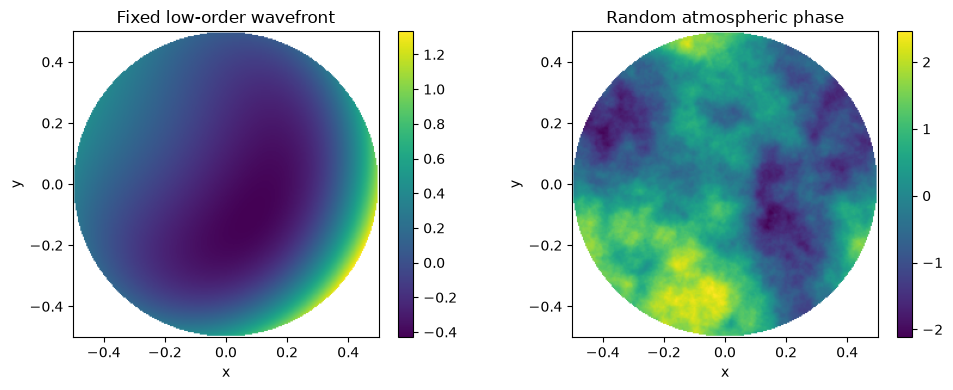

In [7]:
extent = [
    np.nanmin(X),
    np.nanmax(X),
    np.nanmin(Y),
    np.nanmax(Y),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(
    W_fixed,
    extent=extent,
    origin="lower",
)
axes[0].set_title("Fixed low-order wavefront")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(
    W_atm,
    extent=extent,
    origin="lower",
)
axes[1].set_title("Random atmospheric phase")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

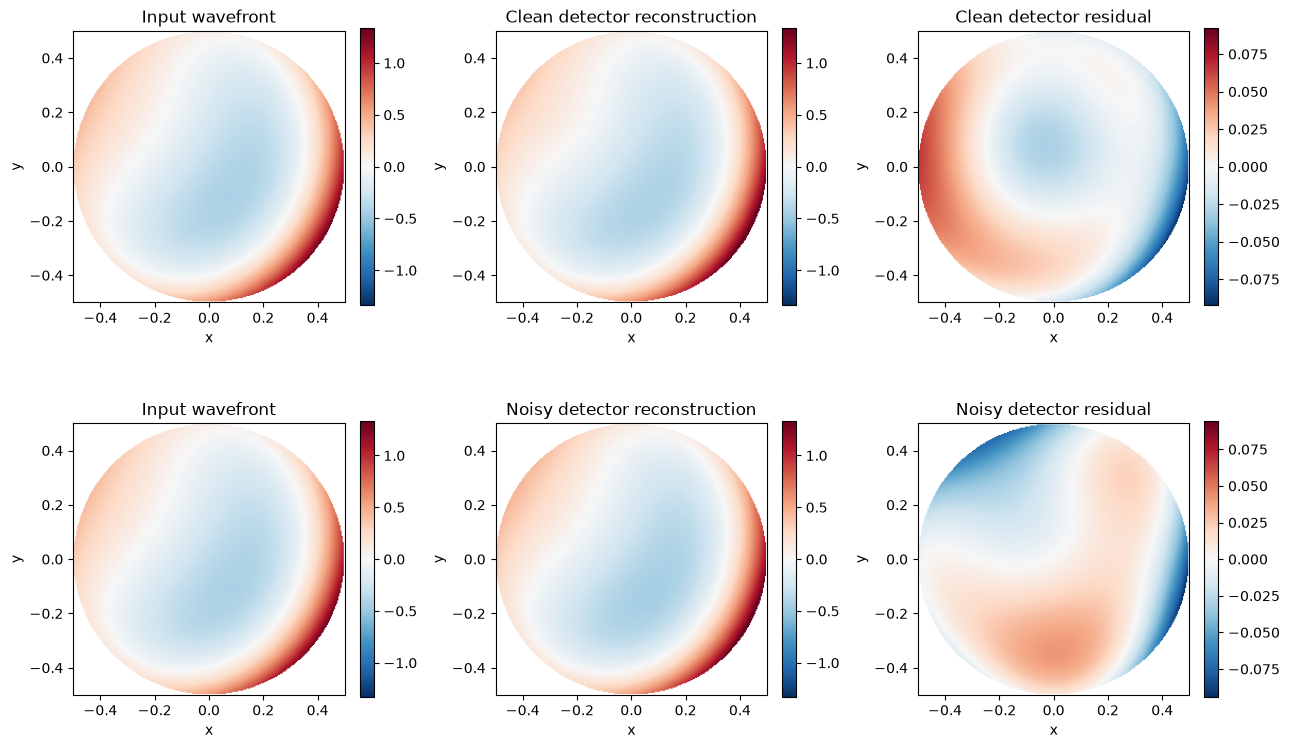

In [8]:
# ------------------------------------------------------------
# Visualize clean vs noisy detector-level reconstruction
# ------------------------------------------------------------

W_rec_clean = result_det_clean["W_rec"]
W_res_clean = result_det_clean["residual"]

W_rec_noisy = result_det_noisy["W_rec"]
W_res_noisy = result_det_noisy["residual"]

vmax = np.nanmax(np.abs(W_test[mask]))

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

items = [
    (W_test, "Input wavefront", vmax),
    (W_rec_clean, "Clean detector reconstruction", vmax),
    (W_res_clean, "Clean detector residual", np.nanmax(np.abs(W_res_clean[mask]))),
    (W_test, "Input wavefront", vmax),
    (W_rec_noisy, "Noisy detector reconstruction", vmax),
    (W_res_noisy, "Noisy detector residual", np.nanmax(np.abs(W_res_noisy[mask]))),
]

for ax, (img, title, scale) in zip(axes.ravel(), items):
    im = ax.imshow(
        np.where(mask, img, np.nan),
        extent=extent,
        origin="lower",
        cmap="RdBu_r",
        vmin=-scale,
        vmax=scale,
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### Detector-level sanity check

This test separates the intrinsic detector-model reconstruction error from noise propagation.

- The clean detector case uses the same centroiding pipeline but disables photon noise, read noise, and background.
- The remaining residual is therefore mainly caused by finite detector sampling, finite detector window size, centroid bias, and modal truncation.
- The noisy detector case includes finite photon statistics, read noise, and background. The increase in residual RMS quantifies the noise propagation from detector images to centroid shifts and finally to modal wavefront reconstruction.

This is more realistic than the ideal geometric SH-WFS model, where local wavefront slopes are measured directly without spot formation, detector sampling, or centroid noise.

In [9]:
#Sanity check
result_fixed = run_wfs_reconstruction(
    W_fixed,
    X,
    Y,
    mask,
    modes,
    n_lenslets=12,
    noise_std=0.0,
    seed=1,
)

print("Estimated coefficients")
print("----------------------")

for name, coeff in zip(result_fixed["names"], result_fixed["coeffs"]):
    true_value = true_coeffs.get(name, 0.0)
    print(f"{name:12s}: true = {true_value:+.4f}, estimated = {coeff:+.4f}")

print()
print(f"Input RMS:    {result_fixed['input_rms']:.4e}")
print(f"Residual RMS: {result_fixed['residual_rms']:.4e}")
print(f"Rank:         {result_fixed['rank']}")

Estimated coefficients
----------------------
tip_x       : true = +0.0500, estimated = +0.0500
tip_y       : true = -0.0300, estimated = -0.0300
defocus     : true = +0.2500, estimated = +0.2500
astig_45    : true = -0.1200, estimated = -0.1200
astig_0     : true = +0.0800, estimated = +0.0800
coma_x      : true = +0.1000, estimated = +0.1000
coma_y      : true = -0.0700, estimated = -0.0700
trefoil_x   : true = +0.0000, estimated = -0.0000
trefoil_y   : true = +0.0000, estimated = +0.0000
spherical   : true = +0.0400, estimated = +0.0400

Input RMS:    3.2096e-01
Residual RMS: 3.2753e-16
Rank:         10


In [10]:
# ------------------------------------------------------------
# Detector diagnostics
# flux, centroid shift, valid centroid map
# ------------------------------------------------------------

diag = result_det_noisy["diag"]
shifts = result_det_noisy["shifts"]

fluxes = diag["fluxes"]
valid = diag["valid"]
shift_norm = np.linalg.norm(shifts, axis=1)

print("Detector diagnostics")
print("--------------------")
print(f"Number of subapertures:     {diag['n_total']}")
print(f"Valid centroids:            {diag['n_valid']}")
print(f"Valid centroid fraction:    {diag['n_valid'] / diag['n_total']:.3f}")
print(f"Median flux:                {np.nanmedian(fluxes):.2f} e-")
print(f"Min flux:                   {np.nanmin(fluxes):.2f} e-")
print(f"Max flux:                   {np.nanmax(fluxes):.2f} e-")
print(f"Median centroid shift:      {np.nanmedian(shift_norm):.3f} px")
print(f"Max centroid shift:         {np.nanmax(shift_norm):.3f} px")

Detector diagnostics
--------------------
Number of subapertures:     156
Valid centroids:            156
Valid centroid fraction:    1.000
Median flux:                19383.37 e-
Min flux:                   18622.00 e-
Max flux:                   19785.89 e-
Median centroid shift:      0.091 px
Max centroid shift:         0.503 px


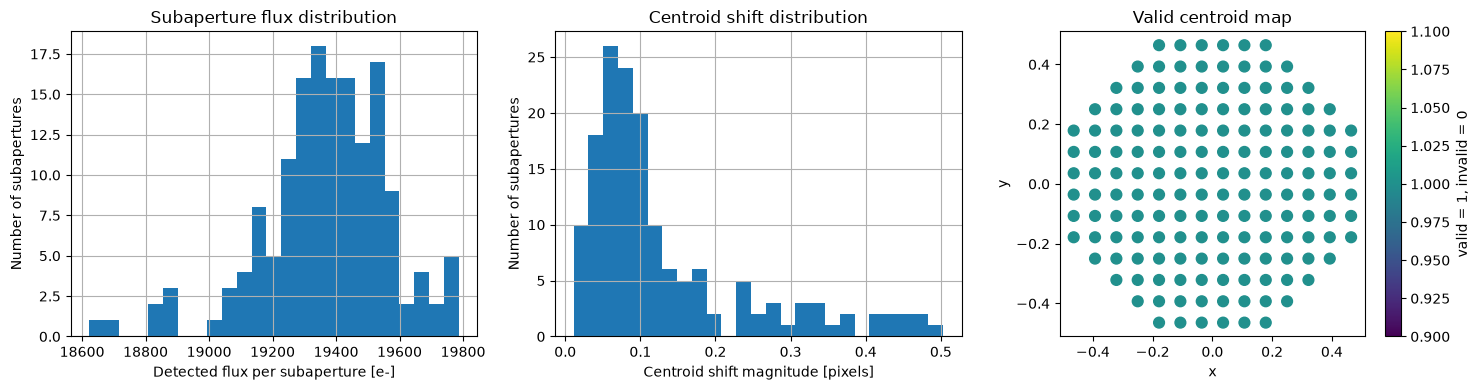

In [11]:
# ------------------------------------------------------------
# Plot detector diagnostics
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Flux distribution
axes[0].hist(fluxes[np.isfinite(fluxes)], bins=25)
axes[0].set_xlabel("Detected flux per subaperture [e-]")
axes[0].set_ylabel("Number of subapertures")
axes[0].set_title("Subaperture flux distribution")
axes[0].grid(True)

# Centroid shift distribution
axes[1].hist(shift_norm[np.isfinite(shift_norm)], bins=25)
axes[1].set_xlabel("Centroid shift magnitude [pixels]")
axes[1].set_ylabel("Number of subapertures")
axes[1].set_title("Centroid shift distribution")
axes[1].grid(True)

# Valid centroid map
sc = axes[2].scatter(
    centers_det[:, 0],
    centers_det[:, 1],
    c=valid.astype(float),
    s=60,
)
axes[2].set_aspect("equal")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_title("Valid centroid map")
plt.colorbar(sc, ax=axes[2], label="valid = 1, invalid = 0")

plt.tight_layout()
plt.show()

### Detector diagnostics

The detector diagnostics check whether the centroid measurements are physically meaningful before they are used for wavefront reconstruction.

- The flux distribution shows how many photo-electrons are detected in each valid subaperture.
- The centroid shift distribution shows whether the spot displacements remain within a reasonable dynamic range.
- The valid centroid map shows which lenslets provide usable centroid measurements.

A low valid fraction would indicate centroid failure, usually caused by insufficient flux, excessive noise, spot clipping, thresholding problems, or very large spot displacements. In that case, reconstruction quality cannot be interpreted only from the modal residual RMS; the detector measurement itself is already failing.

In [12]:
# ------------------------------------------------------------
# Inspect detector spot images
# ------------------------------------------------------------

# Generate detector spots for the same test wavefront used above.
# Here we use the noisy case, because this is closer to detector-level measurement.
#
# RETURN SIGNATURE
# With return_spots=True and return_diagnostics=True, measure_centroid_shifts
# returns (centers, shifts, spots, diagnostics). The first element is the array
# of subaperture CENTRES in pupil coordinates (metres) -- it is not the
# centroids. The measured centroids are in the diagnostics dictionary.

centers_demo, shifts_demo, spots_demo, diag_demo = measure_centroid_shifts(
    W_test,
    mask,
    X,
    Y,
    n_lenslets=detector_cfg["n_lenslets"],
    min_fill=detector_cfg["min_fill"],
    pad_factor=detector_cfg["pad_factor"],
    photons=20000,
    read_noise_e=1.0,
    background_e=1.0,
    threshold_fraction=detector_cfg["threshold_fraction"],
    subtract_minimum=detector_cfg["subtract_minimum"],
    detector_window_size=detector_cfg["detector_window_size"],
    seed=5,
    reference=reference_det,
    masks=masks_det,
    centers=centers_det,
    return_spots=True,
    return_diagnostics=True,
)

# Detector-window quantities, in pixels measured from the window centre with
# the y axis pointing up (this is the convention used by shwfs_detector).
centroids_demo = diag_demo["centroids"]   # measured spot position
reference_demo = diag_demo["reference"]   # zero-slope spot position

# By construction: shifts_demo == centroids_demo - reference_demo.
# The reference is the physically meaningful origin of the measurement, and it
# is not exactly the window centre, so the deviation that must be drawn is
# reference -> centroid, not window centre -> centroid.

print("Spot image inspection")
print("---------------------")
print(f"Number of spot images: {len(spots_demo)}")
print(f"Spot image shape:      {spots_demo[0].shape}")
print(f"Valid centroids:       {diag_demo['n_valid']} / {diag_demo['n_total']}")
print(f"Reference offset from window centre: "
      f"{np.linalg.norm(np.nanmean(reference_demo, axis=0)):.3f} px")
print(f"Max |centroid - reference|:          "
      f"{np.nanmax(np.linalg.norm(shifts_demo, axis=1)):.3f} px")

Spot image inspection
---------------------
Number of spot images: 156
Spot image shape:      (24, 24)
Valid centroids:       156 / 156
Reference offset from window centre: 0.707 px
Max |centroid - reference|:          0.542 px


In [13]:
# ------------------------------------------------------------
# Select representative lenslets
# ------------------------------------------------------------

# Central lenslet: closest to pupil center
idx_center = np.argmin(np.sum(centers_det**2, axis=1))

# Edge lenslet: largest distance from pupil center
idx_edge = np.argmax(np.sum(centers_det**2, axis=1))

# Largest centroid shift
shift_norm_demo = np.linalg.norm(shifts_demo, axis=1)
idx_large_shift = np.nanargmax(shift_norm_demo)

print("Selected lenslets")
print("-----------------")
print(f"Central lenslet index:      {idx_center}")
print(f"Edge lenslet index:         {idx_edge}")
print(f"Largest-shift lenslet index:{idx_large_shift}")
print()
print(f"Central shift:      {shift_norm_demo[idx_center]:.3f} px")
print(f"Edge shift:         {shift_norm_demo[idx_edge]:.3f} px")
print(f"Largest shift:      {shift_norm_demo[idx_large_shift]:.3f} px")

Selected lenslets
-----------------
Central lenslet index:      85
Edge lenslet index:         0
Largest-shift lenslet index:150

Central shift:      0.049 px
Edge shift:         0.139 px
Largest shift:      0.542 px


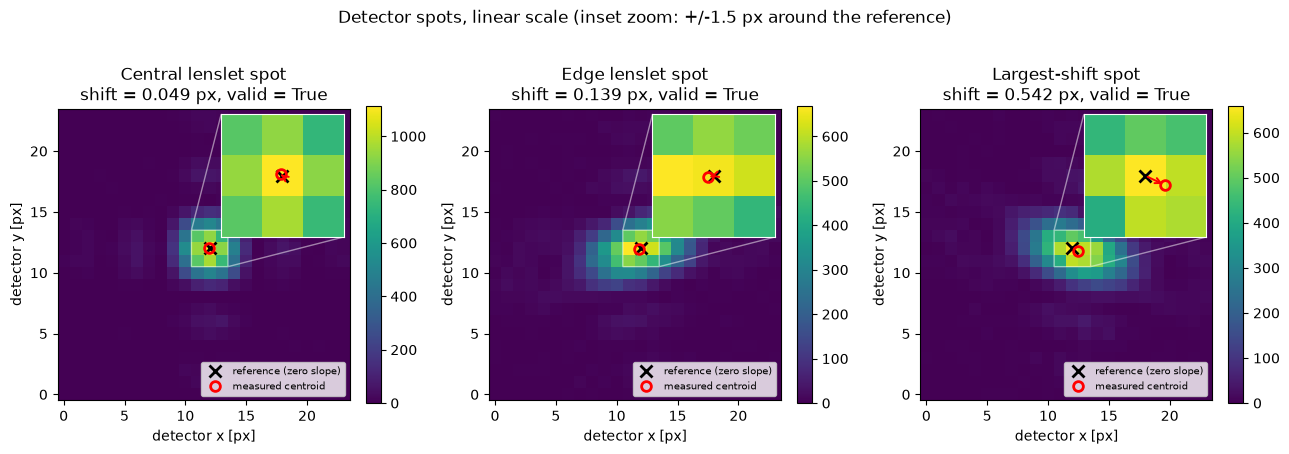

In [14]:
# ------------------------------------------------------------
# Plot representative detector spot images
# ------------------------------------------------------------

spot_items = [
    (idx_center, "Central lenslet spot"),
    (idx_edge, "Edge lenslet spot"),
    (idx_large_shift, "Largest-shift spot"),
]

# Measured shifts are a fraction of a pixel inside a 24 x 24 window, so the
# reference marker and the centroid marker overlap at full-window scale. Every
# panel therefore carries a zoom inset around the reference position; without
# it, two lenslets with very different shifts look identical.
ZOOM_HALF_WIDTH_PX = 1.5


def window_pixel(shape, xy):
    """
    Convert a detector-window coordinate to imshow(origin="lower") pixels.

    Centroids are stored in pixels relative to the window centre with the y
    axis pointing up, while the array row index grows downward:

        column = (n_cols - 1) / 2 + x
        row    = (n_rows - 1) / 2 - y

    With origin="lower" the vertical plot coordinate is the row index, so it
    is cy - y and not cy + y.
    """
    n_rows, n_cols = shape
    x, y = xy
    return (n_cols - 1) / 2.0 + x, (n_rows - 1) / 2.0 - y


def draw_spot_markers(ax, idx, shape, with_arrow=False):
    """Mark the zero-slope reference position and the measured centroid."""
    ref_x, ref_y = window_pixel(shape, reference_demo[idx])
    ax.plot(
        ref_x,
        ref_y,
        "x",
        color="black",
        markersize=8,
        markeredgewidth=2,
        label="reference (zero slope)",
    )

    if not np.all(np.isfinite(centroids_demo[idx])):
        return ref_x, ref_y

    cen_x, cen_y = window_pixel(shape, centroids_demo[idx])
    ax.plot(
        cen_x,
        cen_y,
        "o",
        color="red",
        markersize=7,
        markeredgewidth=2,
        fillstyle="none",
        label="measured centroid",
    )

    # Arrow head size is set in points, so it stays readable for a shift of a
    # few hundredths of a pixel. Only drawn in the zoom inset.
    if with_arrow:
        ax.annotate(
            "",
            xy=(cen_x, cen_y),
            xytext=(ref_x, ref_y),
            arrowprops=dict(arrowstyle="->", color="red", linewidth=1.4),
        )

    return ref_x, ref_y


def plot_spot_panel(ax, idx, title, log_scale=False):
    """Draw one detector window plus a zoom inset on the centroid deviation."""
    spot = spots_demo[idx]
    image = np.log10(np.maximum(spot, 1e-3)) if log_scale else spot

    im = ax.imshow(image, origin="lower", interpolation="nearest")
    ref_x, ref_y = draw_spot_markers(ax, idx, spot.shape)

    # Zoom inset: same data, same colour scale, restricted to the spot core.
    axins = ax.inset_axes([0.56, 0.56, 0.42, 0.42])
    axins.imshow(
        image,
        origin="lower",
        interpolation="nearest",
        norm=im.norm,
        cmap=im.cmap,
    )
    draw_spot_markers(axins, idx, spot.shape, with_arrow=True)
    axins.set_xlim(ref_x - ZOOM_HALF_WIDTH_PX, ref_x + ZOOM_HALF_WIDTH_PX)
    axins.set_ylim(ref_y - ZOOM_HALF_WIDTH_PX, ref_y + ZOOM_HALF_WIDTH_PX)
    axins.set_xticks([])
    axins.set_yticks([])
    for spine in axins.spines.values():
        spine.set_edgecolor("white")
    ax.indicate_inset_zoom(axins, edgecolor="white")

    scale_note = "log10 signal, " if log_scale else ""
    ax.set_title(
        f"{title}\n"
        f"{scale_note}"
        f"shift = {shift_norm_demo[idx]:.3f} px, "
        f"valid = {diag_demo['valid'][idx]}"
    )
    ax.set_xlabel("detector x [px]")
    ax.set_ylabel("detector y [px]")
    ax.legend(fontsize=7, loc="lower right")

    plt.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        label="log10(e-)" if log_scale else None,
    )


fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))

for ax, (idx, title) in zip(axes, spot_items):
    plot_spot_panel(ax, idx, title, log_scale=False)

fig.suptitle(
    f"Detector spots, linear scale "
    f"(inset zoom: +/-{ZOOM_HALF_WIDTH_PX:g} px around the reference)",
    y=1.02,
)
plt.tight_layout()
plt.show()

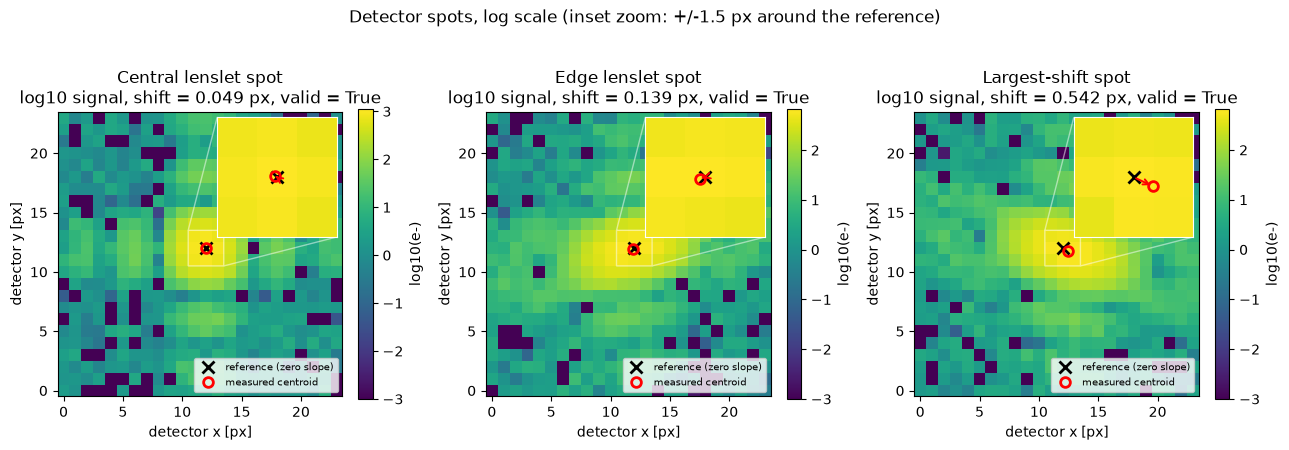

In [15]:
# ------------------------------------------------------------
# Log-display version of detector spots
# ------------------------------------------------------------

# Same panels as above, on a log intensity scale, so that the faint diffraction
# wings and any window clipping become visible. The markers, the zoom inset and
# the coordinate convention are shared with the linear version through
# plot_spot_panel().

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))

for ax, (idx, title) in zip(axes, spot_items):
    plot_spot_panel(ax, idx, title, log_scale=True)

fig.suptitle(
    f"Detector spots, log scale "
    f"(inset zoom: +/-{ZOOM_HALF_WIDTH_PX:g} px around the reference)",
    y=1.02,
)
plt.tight_layout()
plt.show()

### Detector spot image inspection

This section visualizes the actual detector images used for centroiding.

The plotted spots show how local wavefront tilt is converted into a displacement of the focal spot inside each lenslet detector window. The measured centroid is marked on top of the detector image.

This is an important detector-level diagnostic because reconstruction errors can originate before the modal inversion step:

- spot clipping due to a finite detector window,
- poor centroiding due to photon noise or read noise,
- threshold-induced centroid bias,
- large spot displacement outside the linear response regime,
- lower signal quality in partially illuminated edge subapertures.

Therefore, inspecting the spot images helps verify that the SH-WFS measurement itself is physically meaningful before interpreting the reconstructed wavefront residual.

In [16]:
# ------------------------------------------------------------
# Lenslet-number scan with fixed total photon budget
# ------------------------------------------------------------

def detector_lenslet_scan_fixed_total_photons(
    W_true,
    lenslet_values,
    total_photons_per_frame=3e5,
    read_noise_e=1.0,
    background_e=1.0,
    rcond=1e-3,
    seed=10,
):
    """
    Scan the number of SH-WFS lenslets under a fixed total photon budget.

    For each lenslet number:
    - build a detector-level response matrix,
    - distribute the total photons over valid subapertures,
    - measure noisy centroid shifts,
    - reconstruct the wavefront,
    - record residual RMS and detector diagnostics.
    """

    residual_rms_values = []
    rank_values = []
    cond_values = []
    n_valid_values = []
    photons_per_subap_values = []
    valid_fraction_values = []

    for n_lens in lenslet_values:

        cfg = detector_cfg.copy()
        cfg["n_lenslets"] = int(n_lens)

        A_tmp, names_tmp, centers_tmp, masks_tmp, ref_tmp = build_detector_response_matrix(
            modes,
            mask,
            X,
            Y,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
            detector_window_size=cfg["detector_window_size"],
            calibration_amplitude=cfg["calibration_amplitude"],
            differential=True,
        )

        n_valid_subap = len(centers_tmp)

        if n_valid_subap == 0:
            residual_rms_values.append(np.nan)
            rank_values.append(0)
            cond_values.append(np.nan)
            n_valid_values.append(0)
            photons_per_subap_values.append(np.nan)
            valid_fraction_values.append(0.0)
            continue

        photons_per_subap = int(max(total_photons_per_frame / n_valid_subap, 1))

        _, shifts_tmp, diag_tmp = measure_centroid_shifts(
            W_true,
            mask,
            X,
            Y,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            photons=photons_per_subap,
            read_noise_e=read_noise_e,
            background_e=background_e,
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
            detector_window_size=cfg["detector_window_size"],
            seed=seed,
            reference=ref_tmp,
            masks=masks_tmp,
            centers=centers_tmp,
            return_diagnostics=True,
        )

        coeffs_tmp, residuals_tmp, rank_tmp, singular_values_tmp = reconstruct_from_centroid_shifts(
            shifts_tmp,
            A_tmp,
            rcond=rcond,
        )

        W_rec_tmp = synthesize_from_coefficients(
            coeffs_tmp,
            modes,
            names_tmp,
            mask,
            remove_mean=True,
        )

        res_tmp = residual_wavefront(W_true, W_rec_tmp, mask)

        residual_rms_values.append(rms(res_tmp, mask))
        rank_values.append(rank_tmp)
        cond_values.append(singular_values_tmp[0] / singular_values_tmp[-1])
        n_valid_values.append(n_valid_subap)
        photons_per_subap_values.append(photons_per_subap)
        valid_fraction_values.append(diag_tmp["n_valid"] / diag_tmp["n_total"])

    return {
        "lenslets": np.array(lenslet_values),
        "residual_rms": np.array(residual_rms_values),
        "rank": np.array(rank_values),
        "condition_number": np.array(cond_values),
        "n_valid_subapertures": np.array(n_valid_values),
        "photons_per_subaperture": np.array(photons_per_subap_values),
        "valid_fraction": np.array(valid_fraction_values),
    }

In [17]:
# ------------------------------------------------------------
# Run detector-level lenslet scan
# ------------------------------------------------------------

if "W_atm" in globals():
    W_scan = W_atm
    scan_name = "atmospheric phase screen"
else:
    W_scan = W_test
    scan_name = "test wavefront"

lenslet_values = np.array([4, 5, 6, 8, 10, 12, 14, 16, 20])

scan_det = detector_lenslet_scan_fixed_total_photons(
    W_scan,
    lenslet_values=lenslet_values,
    total_photons_per_frame=3e5,
    read_noise_e=1.0,
    background_e=1.0,
    rcond=1e-3,
    seed=10,
)

print(f"Detector lenslet scan using: {scan_name}")
print("------------------------------------------------")
for i, n_lens in enumerate(scan_det["lenslets"]):
    print(
        f"n_lenslets={n_lens:2d} | "
        f"residual RMS={scan_det['residual_rms'][i]:.4e} rad | "
        f"photons/subap={scan_det['photons_per_subaperture'][i]:7.0f} | "
        f"valid subap={scan_det['n_valid_subapertures'][i]:3d} | "
        f"valid frac={scan_det['valid_fraction'][i]:.3f} | "
        f"rank={scan_det['rank'][i]:2d}"
    )

Detector lenslet scan using: atmospheric phase screen
------------------------------------------------
n_lenslets= 4 | residual RMS=6.1802e-01 rad | photons/subap=  25000 | valid subap= 12 | valid frac=1.000 | rank=10
n_lenslets= 5 | residual RMS=7.3802e-01 rad | photons/subap=  14285 | valid subap= 21 | valid frac=1.000 | rank=10
n_lenslets= 6 | residual RMS=7.0271e-01 rad | photons/subap=   9375 | valid subap= 32 | valid frac=1.000 | rank=10
n_lenslets= 8 | residual RMS=6.6143e-01 rad | photons/subap=   5769 | valid subap= 52 | valid frac=1.000 | rank=10
n_lenslets=10 | residual RMS=6.3450e-01 rad | photons/subap=   3750 | valid subap= 80 | valid frac=1.000 | rank=10
n_lenslets=12 | residual RMS=7.2393e-01 rad | photons/subap=   2678 | valid subap=112 | valid frac=1.000 | rank=10
n_lenslets=14 | residual RMS=9.0094e-01 rad | photons/subap=   1923 | valid subap=156 | valid frac=1.000 | rank=10
n_lenslets=16 | residual RMS=1.4031e+00 rad | photons/subap=   1442 | valid subap=208 | vali

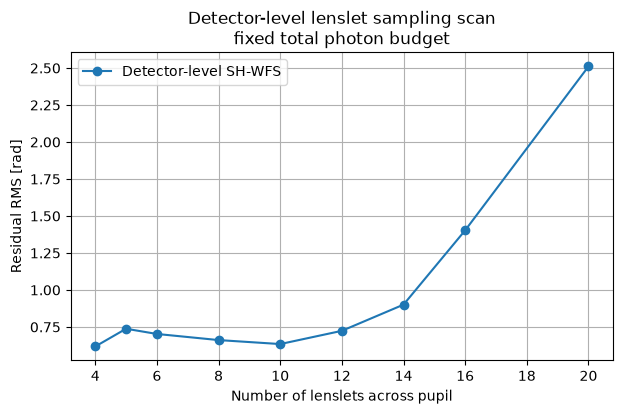

In [18]:
# ------------------------------------------------------------
# Plot residual RMS vs lenslet number
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(
    scan_det["lenslets"],
    scan_det["residual_rms"],
    marker="o",
    label="Detector-level SH-WFS",
)

plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Residual RMS [rad]")
plt.title("Detector-level lenslet sampling scan\nfixed total photon budget")
plt.grid(True)
plt.legend()
plt.show()

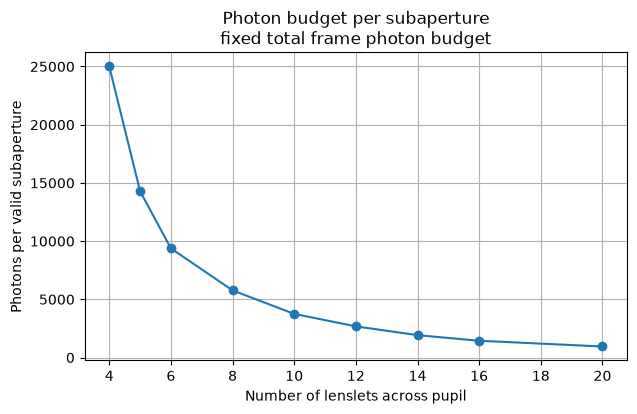

In [19]:
# ------------------------------------------------------------
# Plot photon budget per subaperture
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(
    scan_det["lenslets"],
    scan_det["photons_per_subaperture"],
    marker="o",
)

plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Photons per valid subaperture")
plt.title("Photon budget per subaperture\nfixed total frame photon budget")
plt.grid(True)
plt.show()

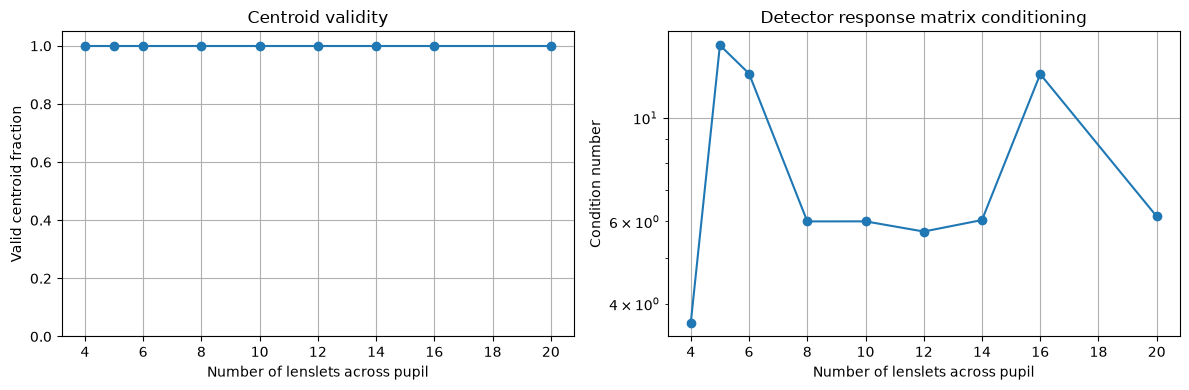

In [20]:
# ------------------------------------------------------------
# Plot detector validity and matrix conditioning
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    scan_det["lenslets"],
    scan_det["valid_fraction"],
    marker="o",
)
axes[0].set_xlabel("Number of lenslets across pupil")
axes[0].set_ylabel("Valid centroid fraction")
axes[0].set_title("Centroid validity")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True)

axes[1].semilogy(
    scan_det["lenslets"],
    scan_det["condition_number"],
    marker="o",
)
axes[1].set_xlabel("Number of lenslets across pupil")
axes[1].set_ylabel("Condition number")
axes[1].set_title("Detector response matrix conditioning")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Lenslet-number scan with fixed total photon budget

This test is more detector realistic than assigning the same photon number to every subaperture.

For a fixed total photon budget, increasing the number of lenslets improves spatial sampling of the wavefront, but it also reduces the number of photons available per subaperture. Therefore, the centroid measurements become noisier at high lenslet counts.

The resulting residual RMS is controlled by a trade-off between:

- spatial sampling error at low lenslet counts,
- centroid noise at high lenslet counts,
- partially illuminated edge subapertures,
- the conditioning of the detector-level response matrix,
- and modal truncation of the reconstructed wavefront.

A minimum in the residual-RMS curve indicates an approximate optimal sampling regime for the chosen wavefront, detector settings, and photon budget.

In [21]:
# ------------------------------------------------------------
# Measured spot clipping vs detector window size
# ------------------------------------------------------------

# reference_centroids builds the zero-phase reference for a given detector
# window without paying for a full response-matrix rebuild. It is part of the
# same shwfs_detector surface the notebook already uses.
from shwfs_detector import reference_centroids

# The canonical window-clipping threshold, read from the library so this
# notebook cannot drift away from it.
from shwfs_ao.detector.validity import DEFAULT_CENTROID_VALIDITY

MAX_WINDOW_CLIPPING_FRACTION = DEFAULT_CENTROID_VALIDITY.max_window_clipping_fraction


def unclipped_spot_reference(
    W_true,
    n_lenslets,
    min_fill,
    pad_factor,
    threshold_fraction,
    subtract_minimum,
):
    """
    Total noiseless energy per lenslet spot with no detector window applied.

    detector_window_size=None keeps the full padded spot, so this is the
    denominator against which a windowed spot is compared.
    """
    centers_ref, masks_ref, reference_ref = reference_centroids(
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
        pad_factor=pad_factor,
        threshold_fraction=threshold_fraction,
        subtract_minimum=subtract_minimum,
        detector_window_size=None,
    )

    _, _, spots_ref, _ = measure_centroid_shifts(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
        pad_factor=pad_factor,
        photons=None,
        read_noise_e=0.0,
        background_e=0.0,
        threshold_fraction=threshold_fraction,
        subtract_minimum=subtract_minimum,
        detector_window_size=None,
        seed=0,
        reference=reference_ref,
        masks=masks_ref,
        centers=centers_ref,
        return_spots=True,
        return_diagnostics=True,
    )

    return np.array([np.sum(spot) for spot in spots_ref])


def measured_clipping_fraction(
    W_true,
    total_energy,
    window_size,
    n_lenslets,
    min_fill,
    pad_factor,
    threshold_fraction,
    subtract_minimum,
):
    """
    Fraction of each lenslet spot's energy that falls outside the window.

        clipping_fraction = 1 - (energy inside window) / (total spot energy)

    The spots are generated noiselessly (photons=None, no read noise, no
    background) so the ratio measures window geometry alone and is not
    contaminated by background summed over a larger window.

    This reproduces the detector telemetry's clipping_fraction exactly.
    """
    centers_w, masks_w, reference_w = reference_centroids(
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
        pad_factor=pad_factor,
        threshold_fraction=threshold_fraction,
        subtract_minimum=subtract_minimum,
        detector_window_size=int(window_size),
    )

    _, _, spots_w, _ = measure_centroid_shifts(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
        pad_factor=pad_factor,
        photons=None,
        read_noise_e=0.0,
        background_e=0.0,
        threshold_fraction=threshold_fraction,
        subtract_minimum=subtract_minimum,
        detector_window_size=int(window_size),
        seed=0,
        reference=reference_w,
        masks=masks_w,
        centers=centers_w,
        return_spots=True,
        return_diagnostics=True,
    )

    windowed_energy = np.array([np.sum(spot) for spot in spots_w])

    return np.clip(1.0 - windowed_energy / total_energy, 0.0, 1.0)

In [22]:
# ------------------------------------------------------------
# Detector window-size scan
# ------------------------------------------------------------

def detector_window_size_scan(
    W_true,
    window_values,
    photons=20000,
    read_noise_e=1.0,
    background_e=1.0,
    rcond=1e-3,
    seed=20,
):
    """
    Scan detector window size for the same lenslet configuration.

    Two different validity numbers are returned.

    valid_fraction
        What measure_centroid_shifts itself reports. On this legacy path the
        sensor is built with a permissive validity configuration (every
        threshold set to a no-op extreme), so this is a finite-centroid check
        only. It is 1.0 whenever the centre of gravity returns a number and
        cannot respond to the window size.

    clipping_valid_fraction
        Fraction of lenslets whose measured spot clipping stays within the
        canonical max_window_clipping_fraction. This is the number that does
        respond to the window size.
    """

    residual_rms_values = []
    valid_fraction_values = []
    median_shift_values = []
    max_shift_values = []
    cond_values = []
    rank_values = []
    clipping_median_values = []
    clipping_max_values = []
    clipping_valid_fraction_values = []

    # Total noiseless spot energy, measured once with no window applied.
    total_energy = unclipped_spot_reference(
        W_true,
        n_lenslets=detector_cfg["n_lenslets"],
        min_fill=detector_cfg["min_fill"],
        pad_factor=detector_cfg["pad_factor"],
        threshold_fraction=detector_cfg["threshold_fraction"],
        subtract_minimum=detector_cfg["subtract_minimum"],
    )

    for win in window_values:

        cfg = detector_cfg.copy()
        cfg["detector_window_size"] = int(win)

        A_tmp, names_tmp, centers_tmp, masks_tmp, ref_tmp = build_detector_response_matrix(
            modes,
            mask,
            X,
            Y,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
            detector_window_size=cfg["detector_window_size"],
            calibration_amplitude=cfg["calibration_amplitude"],
            differential=True,
        )

        _, shifts_tmp, diag_tmp = measure_centroid_shifts(
            W_true,
            mask,
            X,
            Y,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            photons=photons,
            read_noise_e=read_noise_e,
            background_e=background_e,
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
            detector_window_size=cfg["detector_window_size"],
            seed=seed,
            reference=ref_tmp,
            masks=masks_tmp,
            centers=centers_tmp,
            return_diagnostics=True,
        )

        coeffs_tmp, residuals_tmp, rank_tmp, singular_values_tmp = reconstruct_from_centroid_shifts(
            shifts_tmp,
            A_tmp,
            rcond=rcond,
        )

        W_rec_tmp = synthesize_from_coefficients(
            coeffs_tmp,
            modes,
            names_tmp,
            mask,
            remove_mean=True,
        )

        res_tmp = residual_wavefront(W_true, W_rec_tmp, mask)

        shift_norm_tmp = np.linalg.norm(shifts_tmp, axis=1)

        # Physical spot clipping for this window, independent of the
        # permissive validity rule used by measure_centroid_shifts.
        clip_tmp = measured_clipping_fraction(
            W_true,
            total_energy,
            win,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
        )

        clipping_median_values.append(float(np.median(clip_tmp)))
        clipping_max_values.append(float(np.max(clip_tmp)))
        clipping_valid_fraction_values.append(
            float(np.mean(clip_tmp <= MAX_WINDOW_CLIPPING_FRACTION))
        )

        residual_rms_values.append(rms(res_tmp, mask))
        valid_fraction_values.append(diag_tmp["n_valid"] / diag_tmp["n_total"])
        median_shift_values.append(np.nanmedian(shift_norm_tmp))
        max_shift_values.append(np.nanmax(shift_norm_tmp))
        cond_values.append(singular_values_tmp[0] / singular_values_tmp[-1])
        rank_values.append(rank_tmp)

    return {
        "window_size": np.array(window_values),
        "residual_rms": np.array(residual_rms_values),
        "valid_fraction": np.array(valid_fraction_values),
        "median_shift": np.array(median_shift_values),
        "max_shift": np.array(max_shift_values),
        "condition_number": np.array(cond_values),
        "rank": np.array(rank_values),
        "clipping_median": np.array(clipping_median_values),
        "clipping_max": np.array(clipping_max_values),
        "clipping_valid_fraction": np.array(clipping_valid_fraction_values),
    }

In [23]:
# ------------------------------------------------------------
# Run detector window-size scan
# ------------------------------------------------------------

if "W_atm" in globals():
    W_window = W_atm
    window_test_name = "atmospheric phase screen"
else:
    W_window = W_test
    window_test_name = "test wavefront"

window_values = np.array([8, 12, 16, 20, 24, 32, 40, 48])

scan_window = detector_window_size_scan(
    W_window,
    window_values=window_values,
    photons=20000,
    read_noise_e=1.0,
    background_e=1.0,
    rcond=1e-3,
    seed=20,
)

print(f"Detector window-size scan using: {window_test_name}")
print(f"Canonical window-clipping limit: {MAX_WINDOW_CLIPPING_FRACTION:.2f}")
print("-" * 100)
print(
    f"{'window':>9} | {'residual RMS':>16} | {'finite':>7} | "
    f"{'clip med':>8} | {'clip max':>8} | {'clip-gated':>10} | {'max shift':>10}"
)
print("-" * 100)

for i, win in enumerate(scan_window["window_size"]):
    print(
        f"{win:6d} px | "
        f"{scan_window['residual_rms'][i]:12.4e} rad | "
        f"{scan_window['valid_fraction'][i]:7.3f} | "
        f"{scan_window['clipping_median'][i]:8.3f} | "
        f"{scan_window['clipping_max'][i]:8.3f} | "
        f"{scan_window['clipping_valid_fraction'][i]:10.3f} | "
        f"{scan_window['max_shift'][i]:7.3f} px"
    )

print()
print("finite     = valid fraction as reported by measure_centroid_shifts")
print("             (permissive legacy config: a finite-centroid check only)")
print("clip-gated = fraction of lenslets within the canonical clipping limit")

Detector window-size scan using: atmospheric phase screen
Canonical window-clipping limit: 0.15
----------------------------------------------------------------------------------------------------
   window |     residual RMS |  finite | clip med | clip max | clip-gated |  max shift
----------------------------------------------------------------------------------------------------
     8 px |   6.3557e-01 rad |   1.000 |    0.195 |    0.344 |      0.000 |   1.212 px
    12 px |   6.4520e-01 rad |   1.000 |    0.146 |    0.203 |      0.827 |   1.011 px
    16 px |   6.2713e-01 rad |   1.000 |    0.097 |    0.143 |      1.000 |   1.127 px
    20 px |   6.4324e-01 rad |   1.000 |    0.084 |    0.114 |      1.000 |   1.085 px
    24 px |   6.3539e-01 rad |   1.000 |    0.063 |    0.092 |      1.000 |   1.156 px
    32 px |   6.3136e-01 rad |   1.000 |    0.044 |    0.064 |      1.000 |   1.161 px
    40 px |   6.3358e-01 rad |   1.000 |    0.031 |    0.047 |      1.000 |   1.170 px
    48

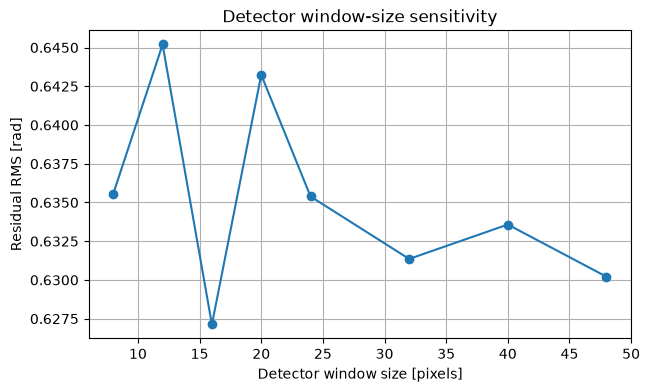

In [24]:
# ------------------------------------------------------------
# Plot residual RMS vs detector window size
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(
    scan_window["window_size"],
    scan_window["residual_rms"],
    marker="o",
)

plt.xlabel("Detector window size [pixels]")
plt.ylabel("Residual RMS [rad]")
plt.title("Detector window-size sensitivity")
plt.grid(True)
plt.show()

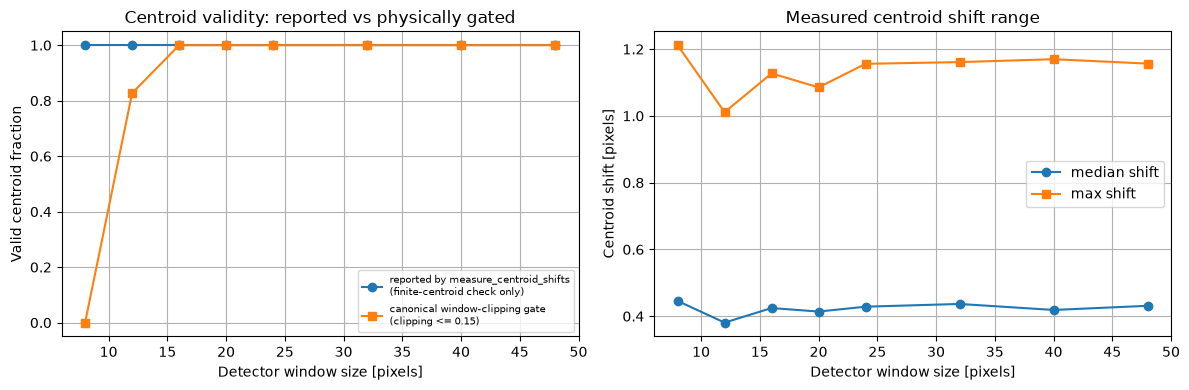

In [25]:
# ------------------------------------------------------------
# Plot centroid validity and shift range
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    scan_window["window_size"],
    scan_window["valid_fraction"],
    marker="o",
    label="reported by measure_centroid_shifts\n(finite-centroid check only)",
)
axes[0].plot(
    scan_window["window_size"],
    scan_window["clipping_valid_fraction"],
    marker="s",
    label=(
        "canonical window-clipping gate\n"
        f"(clipping <= {MAX_WINDOW_CLIPPING_FRACTION:.2f})"
    ),
)
axes[0].set_xlabel("Detector window size [pixels]")
axes[0].set_ylabel("Valid centroid fraction")
axes[0].set_title("Centroid validity: reported vs physically gated")
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True)
axes[0].legend(fontsize=7, loc="lower right")

axes[1].plot(
    scan_window["window_size"],
    scan_window["median_shift"],
    marker="o",
    label="median shift",
)
axes[1].plot(
    scan_window["window_size"],
    scan_window["max_shift"],
    marker="s",
    label="max shift",
)
axes[1].set_xlabel("Detector window size [pixels]")
axes[1].set_ylabel("Centroid shift [pixels]")
axes[1].set_title("Measured centroid shift range")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

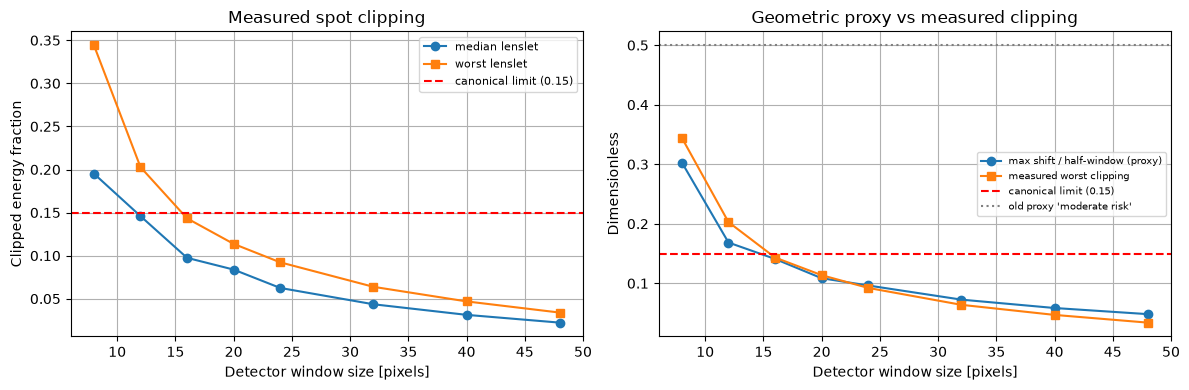

In [26]:
# ------------------------------------------------------------
# Spot-clipping diagnostic
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Measured clipping: the spot energy that falls outside the detector window.
axes[0].plot(
    scan_window["window_size"],
    scan_window["clipping_median"],
    marker="o",
    label="median lenslet",
)
axes[0].plot(
    scan_window["window_size"],
    scan_window["clipping_max"],
    marker="s",
    label="worst lenslet",
)
axes[0].axhline(
    MAX_WINDOW_CLIPPING_FRACTION,
    linestyle="--",
    color="red",
    label=f"canonical limit ({MAX_WINDOW_CLIPPING_FRACTION:.2f})",
)
axes[0].set_xlabel("Detector window size [pixels]")
axes[0].set_ylabel("Clipped energy fraction")
axes[0].set_title("Measured spot clipping")
axes[0].grid(True)
axes[0].legend(fontsize=8)

# The original geometric proxy, shown against the measured value.
#
# The proxy tracks the measured clipping closely here, but its risk levels are
# far too permissive: nothing in this sweep reaches even "moderate risk" (0.5),
# while the real clipping limit is already exceeded at the smallest windows.
geometric_proxy = scan_window["max_shift"] / (scan_window["window_size"] / 2)

axes[1].plot(
    scan_window["window_size"],
    geometric_proxy,
    marker="o",
    label="max shift / half-window (proxy)",
)
axes[1].plot(
    scan_window["window_size"],
    scan_window["clipping_max"],
    marker="s",
    label="measured worst clipping",
)
axes[1].axhline(
    MAX_WINDOW_CLIPPING_FRACTION,
    linestyle="--",
    color="red",
    label=f"canonical limit ({MAX_WINDOW_CLIPPING_FRACTION:.2f})",
)
axes[1].axhline(0.5, linestyle=":", color="gray", label="old proxy 'moderate risk'")
axes[1].set_xlabel("Detector window size [pixels]")
axes[1].set_ylabel("Dimensionless")
axes[1].set_title("Geometric proxy vs measured clipping")
axes[1].grid(True)
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

### Detector window-size scan

This scan tests the effect of finite detector windows on SH-WFS centroid measurements.

A detector window that is too small clips the lenslet focal spot. Clipping removes signal asymmetrically once the spot is displaced by local wavefront tilt, which biases the centroid. Increasing the window reduces clipping, but in a real instrument it also increases detector area, readout cost, and the background collected per subaperture.

**Two different validity numbers are reported, and they do not mean the same thing.**

- `finite` is the valid fraction that `measure_centroid_shifts` returns. This low-level legacy path builds its sensor with a deliberately permissive validity configuration in which every threshold is set to a no-op extreme, so the flag reduces to a finite-centroid check: it is 1.0 whenever the centre of gravity returns a number. With a bright source it is 1.0 at every window size and carries no information about clipping. The full flux / SNR / centroid-uncertainty / window-clipping criteria live in `synthetic_instrument_data.measure_detector_shwfs`.
- `clip-gated` applies the canonical `max_window_clipping_fraction` to the *measured* clipping of each lenslet. This is the number that actually responds to window size.

The clipping fraction itself is measured directly, by comparing the noiseless spot energy inside the window with the total noiseless spot energy. It reproduces the detector telemetry's `clipping_fraction` exactly.

Two further cautions when reading the result:

- The response matrix is rebuilt at every window size with `differential=True`, so a *systematic* clipping bias is largely absorbed into the calibration. Residual RMS is therefore a weak probe of clipping here.
- Only 10 Zernike modes are reconstructed (`rank=10`) against a full atmospheric screen, so the residual is dominated by modal truncation rather than by centroiding quality. This is why the residual-RMS curve stays flat while the clipping fraction changes by an order of magnitude.

The geometric proxy `max shift / half-window` from the original diagnostic is kept for comparison. It tracks the measured clipping closely in this configuration, but its risk levels are far too permissive: no window in this sweep reaches even its "moderate risk" line, while the canonical clipping limit is already exceeded at the smallest windows.

In [27]:
# ------------------------------------------------------------
# Calibration-amplitude scan
# ------------------------------------------------------------

def detector_calibration_amplitude_scan(
    W_true,
    eps_values,
    photons=None,
    read_noise_e=0.0,
    background_e=0.0,
    rcond=1e-3,
    seed=30,
):
    """
    Scan the finite-difference calibration amplitude used to build
    the detector-level SH-WFS response matrix.

    The scan is performed in the clean detector case by default,
    so that the result mainly reflects response-matrix calibration stability.
    """

    residual_rms_values = []
    cond_values = []
    rank_values = []
    valid_fraction_values = []
    min_sv_values = []
    max_sv_values = []

    for eps in eps_values:

        cfg = detector_cfg.copy()
        cfg["calibration_amplitude"] = float(eps)

        A_tmp, names_tmp, centers_tmp, masks_tmp, ref_tmp = build_detector_response_matrix(
            modes,
            mask,
            X,
            Y,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
            detector_window_size=cfg["detector_window_size"],
            calibration_amplitude=cfg["calibration_amplitude"],
            differential=True,
        )

        _, shifts_tmp, diag_tmp = measure_centroid_shifts(
            W_true,
            mask,
            X,
            Y,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            photons=photons,
            read_noise_e=read_noise_e,
            background_e=background_e,
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
            detector_window_size=cfg["detector_window_size"],
            seed=seed,
            reference=ref_tmp,
            masks=masks_tmp,
            centers=centers_tmp,
            return_diagnostics=True,
        )

        coeffs_tmp, residuals_tmp, rank_tmp, singular_values_tmp = reconstruct_from_centroid_shifts(
            shifts_tmp,
            A_tmp,
            rcond=rcond,
        )

        W_rec_tmp = synthesize_from_coefficients(
            coeffs_tmp,
            modes,
            names_tmp,
            mask,
            remove_mean=True,
        )

        res_tmp = residual_wavefront(W_true, W_rec_tmp, mask)

        residual_rms_values.append(rms(res_tmp, mask))
        rank_values.append(rank_tmp)
        valid_fraction_values.append(diag_tmp["n_valid"] / diag_tmp["n_total"])
        max_sv_values.append(singular_values_tmp[0])
        min_sv_values.append(singular_values_tmp[-1])
        cond_values.append(singular_values_tmp[0] / singular_values_tmp[-1])

    return {
        "eps": np.array(eps_values),
        "residual_rms": np.array(residual_rms_values),
        "condition_number": np.array(cond_values),
        "rank": np.array(rank_values),
        "valid_fraction": np.array(valid_fraction_values),
        "max_singular_value": np.array(max_sv_values),
        "min_singular_value": np.array(min_sv_values),
    }

In [28]:
# ------------------------------------------------------------
# Run calibration-amplitude scan
# ------------------------------------------------------------

if "W_fixed" in globals():
    W_calib = W_fixed
    calib_test_name = "fixed low-order Zernike wavefront"
else:
    W_calib = W_test
    calib_test_name = "test wavefront"

eps_values = np.logspace(-5, -1, 7)

scan_calib = detector_calibration_amplitude_scan(
    W_calib,
    eps_values=eps_values,
    photons=None,
    read_noise_e=0.0,
    background_e=0.0,
    rcond=1e-3,
    seed=30,
)

print(f"Calibration-amplitude scan using: {calib_test_name}")
print("------------------------------------------------")
for i, eps in enumerate(scan_calib["eps"]):
    print(
        f"eps={eps:.1e} rad | "
        f"residual RMS={scan_calib['residual_rms'][i]:.4e} rad | "
        f"cond={scan_calib['condition_number'][i]:.3e} | "
        f"rank={scan_calib['rank'][i]:2d} | "
        f"valid frac={scan_calib['valid_fraction'][i]:.3f}"
    )

Calibration-amplitude scan using: fixed low-order Zernike wavefront
------------------------------------------------
eps=1.0e-05 rad | residual RMS=2.4988e-02 rad | cond=6.043e+00 | rank=10 | valid frac=1.000
eps=4.6e-05 rad | residual RMS=2.4988e-02 rad | cond=6.043e+00 | rank=10 | valid frac=1.000
eps=2.2e-04 rad | residual RMS=2.4988e-02 rad | cond=6.043e+00 | rank=10 | valid frac=1.000
eps=1.0e-03 rad | residual RMS=2.4988e-02 rad | cond=6.043e+00 | rank=10 | valid frac=1.000
eps=4.6e-03 rad | residual RMS=2.4989e-02 rad | cond=6.043e+00 | rank=10 | valid frac=1.000
eps=2.2e-02 rad | residual RMS=3.0222e-02 rad | cond=6.131e+00 | rank=10 | valid frac=1.000
eps=1.0e-01 rad | residual RMS=3.3386e-02 rad | cond=6.053e+00 | rank=10 | valid frac=1.000


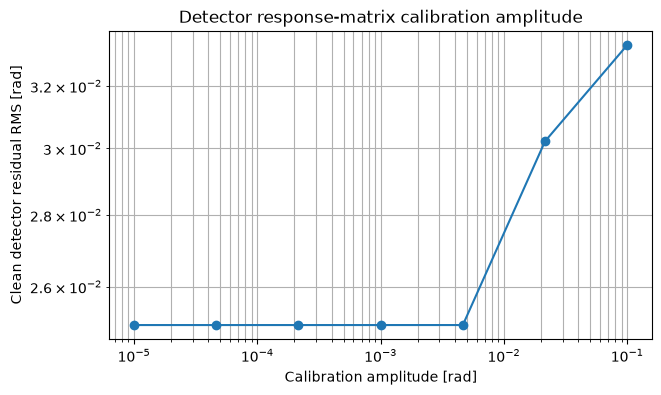

In [29]:
# ------------------------------------------------------------
# Plot residual RMS vs calibration amplitude
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.loglog(
    scan_calib["eps"],
    scan_calib["residual_rms"],
    marker="o",
)

plt.xlabel("Calibration amplitude [rad]")
plt.ylabel("Clean detector residual RMS [rad]")
plt.title("Detector response-matrix calibration amplitude")
plt.grid(True, which="both")
plt.show()

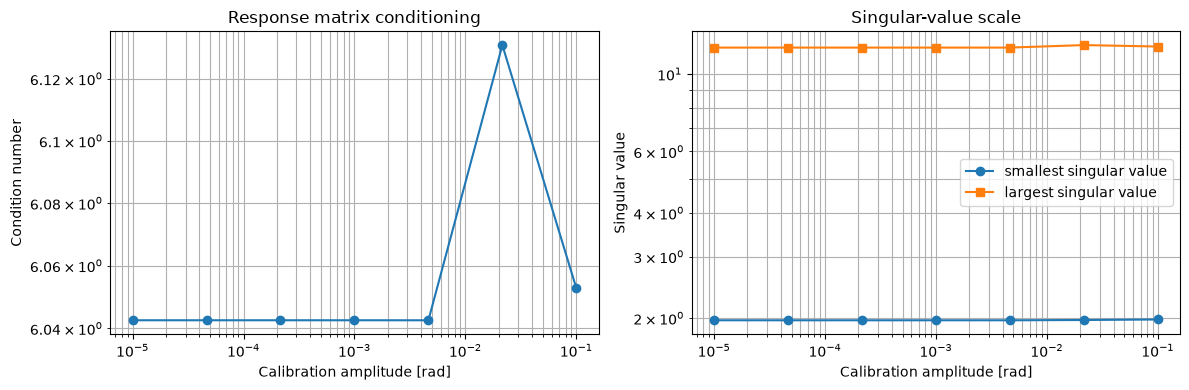

In [30]:
# ------------------------------------------------------------
# Plot conditioning vs calibration amplitude
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(
    scan_calib["eps"],
    scan_calib["condition_number"],
    marker="o",
)
axes[0].set_xlabel("Calibration amplitude [rad]")
axes[0].set_ylabel("Condition number")
axes[0].set_title("Response matrix conditioning")
axes[0].grid(True, which="both")

axes[1].loglog(
    scan_calib["eps"],
    scan_calib["min_singular_value"],
    marker="o",
    label="smallest singular value",
)
axes[1].loglog(
    scan_calib["eps"],
    scan_calib["max_singular_value"],
    marker="s",
    label="largest singular value",
)
axes[1].set_xlabel("Calibration amplitude [rad]")
axes[1].set_ylabel("Singular value")
axes[1].set_title("Singular-value scale")
axes[1].grid(True, which="both")
axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
# ------------------------------------------------------------
# Suggest a stable calibration amplitude
# ------------------------------------------------------------

eps = scan_calib["eps"]
res = scan_calib["residual_rms"]
cond = scan_calib["condition_number"]
rank = scan_calib["rank"]

# Prefer a genuinely small finite-difference amplitude.
# Do not choose a large-amplitude point just because it gives
# a slightly smaller residual for this particular test wavefront.
preferred_eps = 1e-3

idx_ref = np.argmin(np.abs(eps - preferred_eps))
ref_res = res[idx_ref]
ref_cond = cond[idx_ref]
max_rank = np.nanmax(rank)

stable = (
    np.isfinite(res)
    & np.isfinite(cond)
    & (rank == max_rank)
    & (eps >= 1e-5)
    & (eps <= 1e-2)
    & (res <= 1.2 * ref_res)
    & (cond <= 2.0 * ref_cond)
)

if np.any(stable):
    stable_eps = eps[stable]

    # Choose the stable point closest to the preferred small amplitude.
    idx_best_local = np.argmin(np.abs(np.log10(stable_eps) - np.log10(preferred_eps)))
    suggested_eps = stable_eps[idx_best_local]

    idx_suggested = np.where(eps == suggested_eps)[0][0]

    print("Suggested calibration amplitude")
    print("--------------------------------")
    print(f"suggested eps:       {suggested_eps:.2e} rad")
    print(f"residual RMS:        {res[idx_suggested]:.4e} rad")
    print(f"condition number:    {cond[idx_suggested]:.3e}")
    print()
    print("Interpretation:")
    print("The recommendation is chosen from the small-amplitude stable plateau,")
    print("not from the global minimum over all amplitudes.")
else:
    print("No stable small-amplitude plateau found.")
    print("Keep the default eps = 1e-3 rad unless the scan clearly shows instability.")

Suggested calibration amplitude
--------------------------------
suggested eps:       1.00e-03 rad
residual RMS:        2.4988e-02 rad
condition number:    6.043e+00

Interpretation:
The recommendation is chosen from the small-amplitude stable plateau,
not from the global minimum over all amplitudes.


The scan shows that the response matrix is stable over a broad small-amplitude range. Although the largest tested amplitude can sometimes give a lower residual for this specific wavefront, it is not a proper local linear calibration amplitude. Therefore, the default calibration amplitude `1e-3 rad` is retained.

### Calibration-amplitude scan

The detector-level response matrix is calibrated by applying a small positive and negative amplitude to each reconstructed mode and measuring the resulting centroid shifts.

The calibration amplitude must be chosen carefully.

- If the amplitude is too small, the induced centroid displacement becomes comparable to numerical precision, detector sampling effects, or centroiding bias.
- If the amplitude is too large, the spot displacement may leave the linear response regime, and the finite-difference derivative no longer represents the local response.
- A stable plateau in residual RMS and matrix conditioning indicates a suitable calibration regime.

In this notebook, the default value `calibration_amplitude = 1e-3 rad` is used if it lies inside the stable regime of the scan.

Noise Sensitivity Test

In [32]:
#Check how WFS slope measurement noise degrades reconstruction results.
def noise_sensitivity_curve(
    W_true,
    X,
    Y,
    mask,
    modes,
    n_lenslets=12,
    noise_values=None,
    n_trials=10,
):
    """
    Scan measurement noise and compute residual RMS.
    """
    if noise_values is None:
        noise_values = np.array([0.0, 0.002, 0.005, 0.01, 0.02, 0.05])

    mean_residuals = []
    std_residuals = []

    for noise_std in noise_values:
        trial_values = []

        for k in range(n_trials):
            result = run_wfs_reconstruction(
                W_true,
                X,
                Y,
                mask,
                modes,
                n_lenslets=n_lenslets,
                noise_std=noise_std,
                seed=100 + k,
            )

            trial_values.append(result["residual_rms"])

        mean_residuals.append(np.mean(trial_values))
        std_residuals.append(np.std(trial_values))

    return np.array(noise_values), np.array(mean_residuals), np.array(std_residuals)

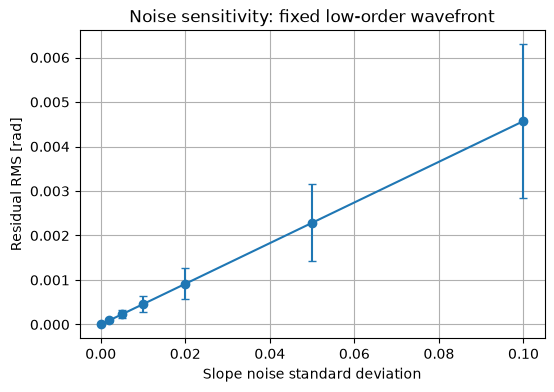

In [33]:
noise_values = np.array([0.0, 0.002, 0.005, 0.01, 0.02, 0.05, 0.10])

noise_fixed, mean_fixed, std_fixed = noise_sensitivity_curve(
    W_fixed,
    X,
    Y,
    mask,
    modes,
    n_lenslets=12,
    noise_values=noise_values,
    n_trials=20,
)

plt.figure(figsize=(6, 4))
plt.errorbar(
    noise_fixed,
    mean_fixed,
    yerr=std_fixed,
    marker="o",
    capsize=3,
)
plt.xlabel("Slope noise standard deviation")
plt.ylabel("Residual RMS [rad]")
plt.title("Noise sensitivity: fixed low-order wavefront")
plt.grid(True)
plt.show()

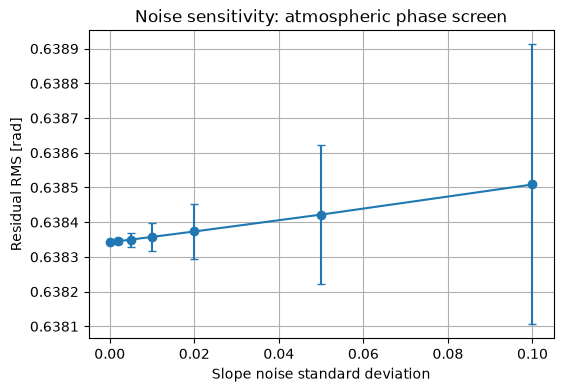

In [34]:
noise_atm, mean_atm, std_atm = noise_sensitivity_curve(
    W_atm,
    X,
    Y,
    mask,
    modes,
    n_lenslets=14,
    noise_values=noise_values,
    n_trials=20,
)

plt.figure(figsize=(6, 4))
plt.errorbar(
    noise_atm,
    mean_atm,
    yerr=std_atm,
    marker="o",
    capsize=3,
)
plt.xlabel("Slope noise standard deviation")
plt.ylabel("Residual RMS [rad]")
plt.title("Noise sensitivity: atmospheric phase screen")
plt.grid(True)
plt.show()

In [35]:
def photon_sensitivity_curve_detector(
    W_true,
    X,
    Y,
    mask,
    modes,
    n_lenslets=14,
    photon_values=None,
    n_trials=10,
    read_noise_e=1.0,
    background_e=2.0,
    pad_factor=4,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
):
    """
    Scan detector photon count and compute reconstruction residual RMS.
    """
    if photon_values is None:
        photon_values = np.array([300, 1000, 3000, 10000, 30000, 100000])

    mean_residuals = []
    std_residuals = []
    valid_fractions = []

    for photons in photon_values:
        trial_values = []
        valid_values = []

        for k in range(n_trials):
            result = run_wfs_reconstruction_detector(
                W_true,
                X,
                Y,
                mask,
                modes,
                n_lenslets=n_lenslets,
                photons=photons,
                read_noise_e=read_noise_e,
                background_e=background_e,
                pad_factor=pad_factor,
                threshold_fraction=threshold_fraction,
                subtract_minimum=subtract_minimum,
                detector_window_size=detector_window_size,
                seed=100 + k,
            )

            trial_values.append(result["residual_rms"])
            valid_values.append(
                result["n_valid_centroids"] / result["n_total_centroids"]
            )

        mean_residuals.append(np.mean(trial_values))
        std_residuals.append(np.std(trial_values))
        valid_fractions.append(np.mean(valid_values))

    return (
        np.asarray(photon_values),
        np.asarray(mean_residuals),
        np.asarray(std_residuals),
        np.asarray(valid_fractions),
    )

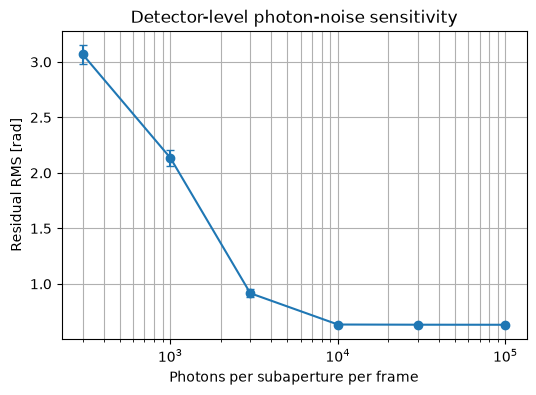

In [36]:
photon_values = np.array([300, 1000, 3000, 10000, 30000, 100000])

photons, mean_det, std_det, valid_frac = photon_sensitivity_curve_detector(
    W_atm,
    X,
    Y,
    mask,
    modes,
    n_lenslets=14,
    photon_values=photon_values,
    n_trials=10,
    read_noise_e=1.0,
    background_e=2.0,
    pad_factor=4,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
)

plt.figure(figsize=(6, 4))
plt.errorbar(
    photons,
    mean_det,
    yerr=std_det,
    marker="o",
    capsize=3,
)
plt.xscale("log")
plt.xlabel("Photons per subaperture per frame")
plt.ylabel("Residual RMS [rad]")
plt.title("Detector-level photon-noise sensitivity")
plt.grid(True, which="both")
plt.show()

The impact of sub-aperture quantity on the quality of reconstruction

In [37]:
def lenslet_number_scan(
    W_true,
    X,
    Y,
    mask,
    modes,
    lenslet_values=None,
    noise_std=0.0,
):
    """
    Scan number of lenslets across the pupil and compute residual RMS.
    """
    if lenslet_values is None:
        lenslet_values = np.array([6, 8, 10, 12, 14, 16, 20, 24])

    residual_values = []
    rank_values = []
    n_subap_values = []

    for n_lenslets in lenslet_values:
        result = run_wfs_reconstruction(
            W_true,
            X,
            Y,
            mask,
            modes,
            n_lenslets=int(n_lenslets),
            noise_std=noise_std,
            seed=1,
        )

        residual_values.append(result["residual_rms"])
        rank_values.append(result["rank"])
        n_subap_values.append(len(result["centers"]))

    return (
        np.array(lenslet_values),
        np.array(residual_values),
        np.array(rank_values),
        np.array(n_subap_values),
    )

def lenslet_number_scan_detector(
    W_true,
    X,
    Y,
    mask,
    modes,
    lenslet_values=None,
    total_photons_per_frame=3e5,
    read_noise_e=1.0,
    background_e=2.0,
    pad_factor=4,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
):
    if lenslet_values is None:
        lenslet_values = np.array([6, 8, 10, 12, 14, 16, 20])

    residual_values = []
    rank_values = []
    n_subap_values = []
    photons_per_subap_values = []

    for n_lenslets in lenslet_values:
        # First build response matrix to know the number of valid subapertures.
        A_det, names, centers, masks_det, reference = build_detector_response_matrix(
            modes,
            mask,
            X,
            Y,
            n_lenslets=int(n_lenslets),
            min_fill=0.5,
            pad_factor=pad_factor,
            threshold_fraction=threshold_fraction,
            subtract_minimum=subtract_minimum,
            detector_window_size=detector_window_size,
            calibration_amplitude=1e-3,
            differential=True,
        )

        photons_per_subap = total_photons_per_frame / len(centers)

        _, shifts, diag = measure_centroid_shifts(
            W_true,
            mask,
            X,
            Y,
            n_lenslets=int(n_lenslets),
            min_fill=0.5,
            pad_factor=pad_factor,
            photons=photons_per_subap,
            read_noise_e=read_noise_e,
            background_e=background_e,
            threshold_fraction=threshold_fraction,
            subtract_minimum=subtract_minimum,
            detector_window_size=detector_window_size,
            reference=reference,
            masks=masks_det,
            centers=centers,
            return_diagnostics=True,
        )

        coeffs, residuals, rank, singular_values = reconstruct_from_centroid_shifts(
            shifts,
            A_det,
            rcond=1e-3,
        )

        W_rec = synthesize_from_coefficients(
            coeffs,
            modes,
            names,
            mask,
            remove_mean=True,
        )

        res = residual_wavefront(W_true, W_rec, mask)

        residual_values.append(rms(res, mask))
        rank_values.append(rank)
        n_subap_values.append(len(centers))
        photons_per_subap_values.append(photons_per_subap)

    return (
        np.asarray(lenslet_values),
        np.asarray(residual_values),
        np.asarray(rank_values),
        np.asarray(n_subap_values),
        np.asarray(photons_per_subap_values),
    )

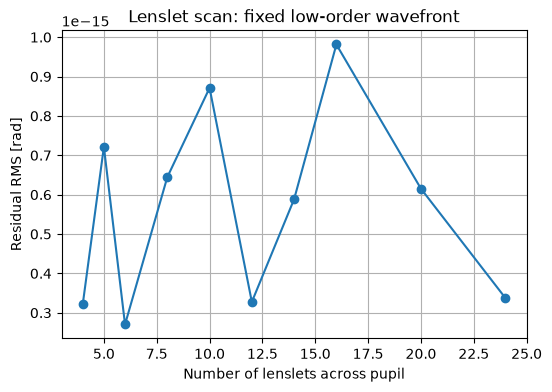

n_lenslets =  4, valid subapertures =  12, rank = 10, residual RMS = 3.2158e-16
n_lenslets =  5, valid subapertures =  21, rank = 10, residual RMS = 7.2147e-16
n_lenslets =  6, valid subapertures =  32, rank = 10, residual RMS = 2.7021e-16
n_lenslets =  8, valid subapertures =  52, rank = 10, residual RMS = 6.4434e-16
n_lenslets = 10, valid subapertures =  80, rank = 10, residual RMS = 8.7106e-16
n_lenslets = 12, valid subapertures = 112, rank = 10, residual RMS = 3.2753e-16
n_lenslets = 14, valid subapertures = 156, rank = 10, residual RMS = 5.8845e-16
n_lenslets = 16, valid subapertures = 208, rank = 10, residual RMS = 9.8138e-16
n_lenslets = 20, valid subapertures = 316, rank = 10, residual RMS = 6.1522e-16
n_lenslets = 24, valid subapertures = 450, rank = 10, residual RMS = 3.3723e-16


In [38]:
lenslet_values = np.array([4, 5, 6, 8, 10, 12, 14, 16, 20, 24])

lens_fixed, res_fixed, rank_fixed, nsub_fixed = lenslet_number_scan(
    W_fixed,
    X,
    Y,
    mask,
    modes,
    lenslet_values=lenslet_values,
    noise_std=0.0,
)

plt.figure(figsize=(6, 4))
plt.plot(
    lens_fixed,
    res_fixed,
    marker="o",
)
plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Residual RMS [rad]")
plt.title("Lenslet scan: fixed low-order wavefront")
plt.grid(True)
plt.show()

for n, nsub, rank, res in zip(lens_fixed, nsub_fixed, rank_fixed, res_fixed):
    print(
        f"n_lenslets = {n:2d}, "
        f"valid subapertures = {nsub:3d}, "
        f"rank = {rank:2d}, "
        f"residual RMS = {res:.4e}"
    )

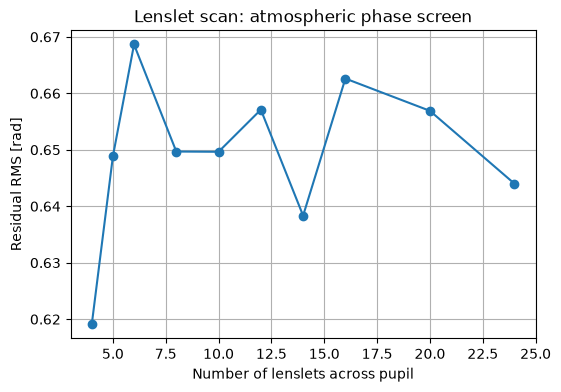

n_lenslets =  4, valid subapertures =  12, rank = 10, residual RMS = 6.1906e-01
n_lenslets =  5, valid subapertures =  21, rank = 10, residual RMS = 6.4883e-01
n_lenslets =  6, valid subapertures =  32, rank = 10, residual RMS = 6.6865e-01
n_lenslets =  8, valid subapertures =  52, rank = 10, residual RMS = 6.4969e-01
n_lenslets = 10, valid subapertures =  80, rank = 10, residual RMS = 6.4965e-01
n_lenslets = 12, valid subapertures = 112, rank = 10, residual RMS = 6.5711e-01
n_lenslets = 14, valid subapertures = 156, rank = 10, residual RMS = 6.3834e-01
n_lenslets = 16, valid subapertures = 208, rank = 10, residual RMS = 6.6262e-01
n_lenslets = 20, valid subapertures = 316, rank = 10, residual RMS = 6.5690e-01
n_lenslets = 24, valid subapertures = 450, rank = 10, residual RMS = 6.4400e-01


In [39]:
lens_atm, res_atm, rank_atm, nsub_atm = lenslet_number_scan(
    W_atm,
    X,
    Y,
    mask,
    modes,
    lenslet_values=lenslet_values,
    noise_std=0.0,
)

plt.figure(figsize=(6, 4))
plt.plot(
    lens_atm,
    res_atm,
    marker="o",
)
plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Residual RMS [rad]")
plt.title("Lenslet scan: atmospheric phase screen")
plt.grid(True)
plt.show()

for n, nsub, rank, res in zip(lens_atm, nsub_atm, rank_atm, res_atm):
    print(
        f"n_lenslets = {n:2d}, "
        f"valid subapertures = {nsub:3d}, "
        f"rank = {rank:2d}, "
        f"residual RMS = {res:.4e}"
    )

In this experiment, increasing the number of lenslets does not necessarily lead to a monotonic decrease of the residual wavefront error. This is because the number of reconstructed modes is kept fixed. The Shack-Hartmann sensor samples the local slopes more finely as the number of sub-apertures increases, but the reconstructor still projects the measured slopes onto the same low-order Zernike-like modal basis.

For atmospheric turbulence, the wavefront contains high-spatial-frequency aberrations that cannot be represented by this limited modal basis. Therefore, increasing the WFS sampling alone does not remove the high-order residual. In some cases, finer sampling can even introduce more high-frequency slope information into the least-squares fit, which may slightly change the estimated low-order coefficients and produce non-monotonic residual RMS behavior.

A physically more complete AO simulation would increase both the WFS sampling and the number of controllable modes or DM actuators.

An increased number of lenslets enhances slope sampling;
however, the reconstruction basis remains limited to low-order Zernike modes,
consequently, high-order turbulent structures still cannot be fitted.

Low order AO Correction demo

In [40]:
result_atm = run_wfs_reconstruction(
    W_atm,
    X,
    Y,
    mask,
    modes,
    n_lenslets=14,
    noise_std=0.01,
    seed=2,
)

W_rec = result_atm["W_rec"]
W_corrected = result_atm["residual"]

print(f"Atmospheric RMS before correction: {rms(W_atm, mask):.4f} rad")
print(f"Residual RMS after correction:     {rms(W_corrected, mask):.4f} rad")
print(f"RMS reduction factor:              {rms(W_atm, mask) / rms(W_corrected, mask):.3f}")

Atmospheric RMS before correction: 1.0012 rad
Residual RMS after correction:     0.6383 rad
RMS reduction factor:              1.569


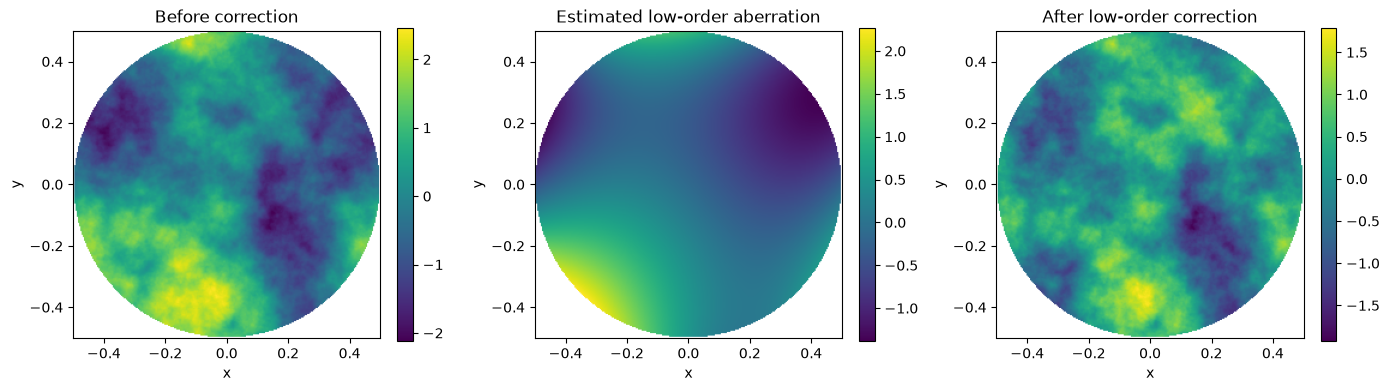

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(
    W_atm,
    extent=extent,
    origin="lower",
)
axes[0].set_title("Before correction")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(
    W_rec,
    extent=extent,
    origin="lower",
)
axes[1].set_title("Estimated low-order aberration")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(
    W_corrected,
    extent=extent,
    origin="lower",
)
axes[2].set_title("After low-order correction")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

In [42]:
# ------------------------------------------------------------
# Detector-level low-order AO correction
# ------------------------------------------------------------

if "W_atm" not in globals():
    raise RuntimeError("W_atm is not defined. Please run the atmospheric phase-screen cell first.")

# Geometric baseline, if the helper function exists
if "run_wfs_reconstruction" in globals():
    result_atm_geo = run_wfs_reconstruction(
        W_atm,
        X,
        Y,
        mask,
        modes,
        n_lenslets=detector_cfg["n_lenslets"],
        noise_std=0.01,
        seed=2,
    )
else:
    result_atm_geo = None

# Detector-level reconstruction using cached detector response matrix
result_atm_det = run_detector_cached(
    W_atm,
    photons=20000,
    read_noise_e=1.0,
    background_e=1.0,
    seed=2,
    rcond=1e-3,
)

W_rec_det = result_atm_det["W_rec"]
W_corr_det = result_atm_det["residual"]

print("Detector-level AO correction")
print("----------------------------")
print(f"Input RMS:               {result_atm_det['input_rms']:.4e} rad")
print(f"Detector residual RMS:   {result_atm_det['residual_rms']:.4e} rad")
print(f"Correction factor:       {result_atm_det['input_rms'] / result_atm_det['residual_rms']:.3f}")
print(f"Valid centroid fraction: {result_atm_det['valid_fraction']:.3f}")
print(f"Reconstruction rank:     {result_atm_det['rank']}")

if result_atm_geo is not None:
    W_rec_geo = result_atm_geo["W_rec"]
    W_corr_geo = result_atm_geo["residual"]

    print("\nGeometric baseline")
    print("------------------")
    print(f"Geometric residual RMS:  {result_atm_geo['residual_rms']:.4e} rad")
    print(f"Correction factor:       {result_atm_geo['input_rms'] / result_atm_geo['residual_rms']:.3f}")

Detector-level AO correction
----------------------------
Input RMS:               1.0012e+00 rad
Detector residual RMS:   6.3538e-01 rad
Correction factor:       1.576
Valid centroid fraction: 1.000
Reconstruction rank:     10

Geometric baseline
------------------
Geometric residual RMS:  6.3833e-01 rad
Correction factor:       1.569


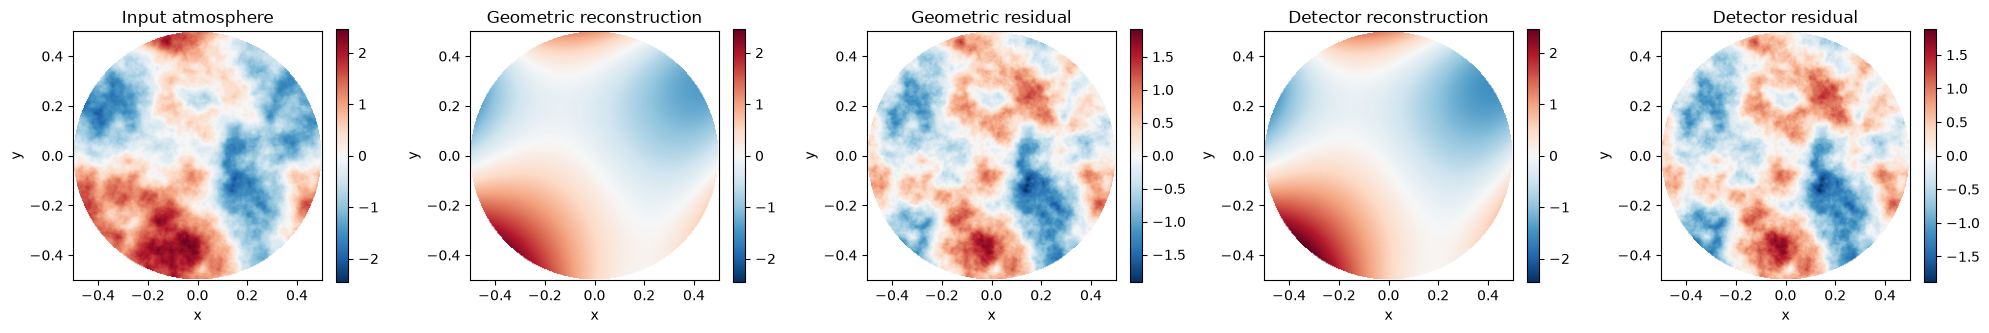

In [43]:
# ------------------------------------------------------------
# Visualize detector-level AO correction
# ------------------------------------------------------------

if result_atm_geo is not None:
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    vmax_wave = np.nanmax(np.abs(W_atm[mask]))
    vmax_geo_res = np.nanmax(np.abs(W_corr_geo[mask]))
    vmax_det_res = np.nanmax(np.abs(W_corr_det[mask]))

    items = [
        (W_atm, "Input atmosphere", vmax_wave),
        (W_rec_geo, "Geometric reconstruction", vmax_wave),
        (W_corr_geo, "Geometric residual", vmax_geo_res),
        (W_rec_det, "Detector reconstruction", vmax_wave),
        (W_corr_det, "Detector residual", vmax_det_res),
    ]

else:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    vmax_wave = np.nanmax(np.abs(W_atm[mask]))
    vmax_det_res = np.nanmax(np.abs(W_corr_det[mask]))

    items = [
        (W_atm, "Input atmosphere", vmax_wave),
        (W_rec_det, "Detector reconstruction", vmax_wave),
        (W_corr_det, "Detector residual", vmax_det_res),
    ]

for ax, (img, title, scale) in zip(np.ravel(axes), items):
    im = ax.imshow(
        np.where(mask, img, np.nan),
        extent=extent,
        origin="lower",
        cmap="RdBu_r",
        vmin=-scale,
        vmax=scale,
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

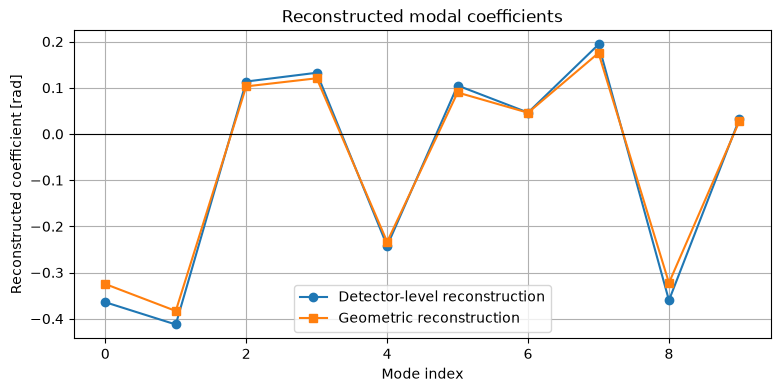

In [44]:
# ------------------------------------------------------------
# Compare reconstructed modal coefficients
# ------------------------------------------------------------

coeff_det = result_atm_det["coeffs"]

plt.figure(figsize=(9, 4))

plt.plot(
    np.arange(len(coeff_det)),
    coeff_det,
    marker="o",
    label="Detector-level reconstruction",
)

if result_atm_geo is not None and "coeffs" in result_atm_geo:
    coeff_geo = result_atm_geo["coeffs"]
    plt.plot(
        np.arange(len(coeff_geo)),
        coeff_geo,
        marker="s",
        label="Geometric reconstruction",
    )

plt.axhline(0.0, color="k", linewidth=0.8)
plt.xlabel("Mode index")
plt.ylabel("Reconstructed coefficient [rad]")
plt.title("Reconstructed modal coefficients")
plt.grid(True)
plt.legend()
plt.show()

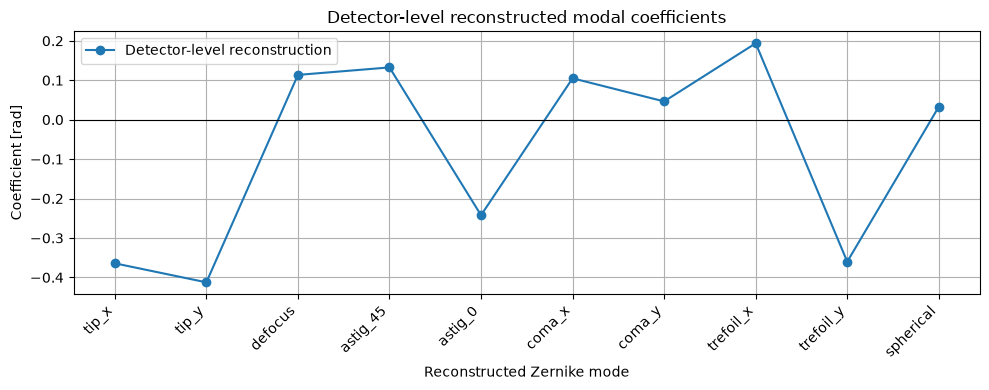

In [45]:
plt.figure(figsize=(10, 4))

plt.plot(
    np.arange(len(coeff_det)),
    coeff_det,
    marker="o",
    label="Detector-level reconstruction",
)

plt.xticks(
    np.arange(len(names_det)),
    names_det,
    rotation=45,
    ha="right",
)

plt.axhline(0.0, color="k", linewidth=0.8)
plt.xlabel("Reconstructed Zernike mode")
plt.ylabel("Coefficient [rad]")
plt.title("Detector-level reconstructed modal coefficients")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# ------------------------------------------------------------
# Residual statistics
# ------------------------------------------------------------

def print_wavefront_stats(label, W):
    values = W[mask]
    print(f"{label}")
    print("-" * len(label))
    print(f"RMS:     {rms(W, mask):.4e} rad")
    print(f"Mean:    {np.nanmean(values):.4e} rad")
    print(f"Std:     {np.nanstd(values):.4e} rad")
    print(f"Min:     {np.nanmin(values):.4e} rad")
    print(f"Max:     {np.nanmax(values):.4e} rad")
    print()

print_wavefront_stats("Input atmosphere", W_atm)

if result_atm_geo is not None:
    print_wavefront_stats("Geometric residual", W_corr_geo)

print_wavefront_stats("Detector-level residual", W_corr_det)

Input atmosphere
----------------
RMS:     1.0012e+00 rad
Mean:    3.1928e-03 rad
Std:     1.0012e+00 rad
Min:     -2.1130e+00 rad
Max:     2.4584e+00 rad

Geometric residual
------------------
RMS:     6.3833e-01 rad
Mean:    4.4548e-18 rad
Std:     6.3833e-01 rad
Min:     -1.9183e+00 rad
Max:     1.7867e+00 rad

Detector-level residual
-----------------------
RMS:     6.3538e-01 rad
Mean:    1.1137e-17 rad
Std:     6.3538e-01 rad
Min:     -1.8827e+00 rad
Max:     1.7625e+00 rad



### Detector-level low-order AO correction

This section applies the detector-level SH-WFS pipeline to a turbulent atmospheric phase screen.

Unlike the ideal geometric model, the detector-level reconstruction does not measure local wavefront slopes directly. Instead, it forms lenslet focal spots, adds detector noise, estimates centroid shifts, and reconstructs the low-order modal wavefront from those noisy centroid measurements.

The detector-level residual therefore includes several additional error sources:

- finite detector sampling,
- finite detector window size,
- photon noise,
- read noise,
- background noise,
- centroid bias,
- response-matrix conditioning,
- and modal truncation.

The geometric reconstruction should be interpreted as an idealized upper-performance baseline, while the detector-level reconstruction is closer to a physically realistic SH-WFS measurement chain.

Comparison of different turbulence

In [47]:
# ------------------------------------------------------------
# Turbulence seed comparison:
# geometric baseline vs detector-level reconstruction
# ------------------------------------------------------------

seeds = [1, 2, 3, 4, 5, 10, 20, 30]

before_values = []
after_geo_values = []
after_det_values = []

for seed in seeds:
    W_tmp = make_random_atmospheric_wavefront(
        N=N,
        dx=dx,
        pupil_mask=mask,
        diameter=diameter,
        r0=0.20,
        L0=25.0,
        seed=seed,
        target_rms_rad=1.0,
    )

    # Idealized geometric SH-WFS baseline
    result_geo_tmp = run_wfs_reconstruction(
        W_tmp,
        X,
        Y,
        mask,
        modes,
        n_lenslets=detector_cfg["n_lenslets"],
        noise_std=0.01,
        seed=100 + seed,
    )

    # Detector-level SH-WFS reconstruction
    result_det_tmp = run_detector_cached(
        W_tmp,
        photons=20000,
        read_noise_e=1.0,
        background_e=1.0,
        seed=200 + seed,
        rcond=1e-3,
    )

    before_values.append(rms(W_tmp, mask))
    after_geo_values.append(result_geo_tmp["residual_rms"])
    after_det_values.append(result_det_tmp["residual_rms"])

before_values = np.array(before_values)
after_geo_values = np.array(after_geo_values)
after_det_values = np.array(after_det_values)

print("Turbulence seed comparison")
print("--------------------------")
print(f"Mean RMS before correction:       {np.mean(before_values):.4f} rad")
print(f"Mean RMS after geometric AO:      {np.mean(after_geo_values):.4f} rad")
print(f"Mean RMS after detector AO:       {np.mean(after_det_values):.4f} rad")
print()
print(f"Mean geometric reduction factor:  {np.mean(before_values / after_geo_values):.3f}")
print(f"Mean detector reduction factor:   {np.mean(before_values / after_det_values):.3f}")

Turbulence seed comparison
--------------------------
Mean RMS before correction:       1.0007 rad
Mean RMS after geometric AO:      0.5535 rad
Mean RMS after detector AO:       0.5513 rad

Mean geometric reduction factor:  1.860
Mean detector reduction factor:   1.875


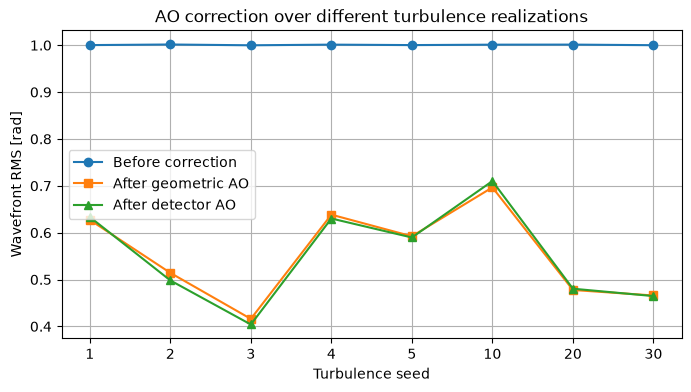

In [48]:
# ------------------------------------------------------------
# Plot turbulence seed comparison
# ------------------------------------------------------------

x = np.arange(len(seeds))

plt.figure(figsize=(8, 4))

plt.plot(
    x,
    before_values,
    marker="o",
    label="Before correction",
)

plt.plot(
    x,
    after_geo_values,
    marker="s",
    label="After geometric AO",
)

plt.plot(
    x,
    after_det_values,
    marker="^",
    label="After detector AO",
)

plt.xticks(x, seeds)
plt.xlabel("Turbulence seed")
plt.ylabel("Wavefront RMS [rad]")
plt.title("AO correction over different turbulence realizations")
plt.grid(True)
plt.legend()
plt.show()

PSF and Strehl-ratio

In [49]:
def compute_psf_from_phase(phase_rad, mask, pad_factor=4):
    """
    Compute focal-plane PSF from pupil phase.

    Parameters
    ----------
    phase_rad : ndarray
        Phase aberration in radians.
    mask : ndarray
        Pupil mask.
    pad_factor : int
        Zero-padding factor for better PSF sampling.

    Returns
    -------
    psf : ndarray
        Normalized PSF.
    """
    N = phase_rad.shape[0]

    pupil_field = np.zeros_like(phase_rad, dtype=complex)
    phase_clean = np.nan_to_num(phase_rad, nan=0.0)

    pupil_field[mask] = np.exp(1j * phase_clean[mask])

    pad_N = pad_factor * N
    padded = np.zeros((pad_N, pad_N), dtype=complex)

    start = (pad_N - N) // 2
    end = start + N
    padded[start:end, start:end] = pupil_field

    focal_field = np.fft.fftshift(
        np.fft.fft2(
            np.fft.ifftshift(padded)
        )
    )

    psf = np.abs(focal_field) ** 2
    psf /= np.sum(psf)

    return psf


def strehl_ratio(phase_rad, mask, pad_factor=4):
    """
    Compute approximate Strehl ratio.

    Strehl = peak aberrated PSF / peak diffraction-limited PSF
    """
    psf_aberrated = compute_psf_from_phase(
        phase_rad,
        mask,
        pad_factor=pad_factor,
    )

    ideal_phase = np.zeros_like(phase_rad)

    psf_ideal = compute_psf_from_phase(
        ideal_phase,
        mask,
        pad_factor=pad_factor,
    )

    return np.max(psf_aberrated) / np.max(psf_ideal)

In [50]:
# ------------------------------------------------------------
# PSF and Strehl: detector-level AO correction
# ------------------------------------------------------------

pad_factor_psf = 4

psf_ideal = compute_psf_from_phase(
    np.zeros_like(W_atm),
    mask,
    pad_factor=pad_factor_psf,
)

psf_before = compute_psf_from_phase(
    W_atm,
    mask,
    pad_factor=pad_factor_psf,
)

psf_after_det = compute_psf_from_phase(
    W_corr_det,
    mask,
    pad_factor=pad_factor_psf,
)

ideal_peak = np.max(psf_ideal)

strehl_before = np.max(psf_before) / ideal_peak
strehl_after_det = np.max(psf_after_det) / ideal_peak

print(f"Strehl before correction:          {strehl_before:.4f}")
print(f"Strehl after detector-level AO:    {strehl_after_det:.4f}")
print(f"Improvement factor:                {strehl_after_det / strehl_before:.3f}")

Strehl before correction:          0.4573
Strehl after detector-level AO:    0.6628
Improvement factor:                1.449


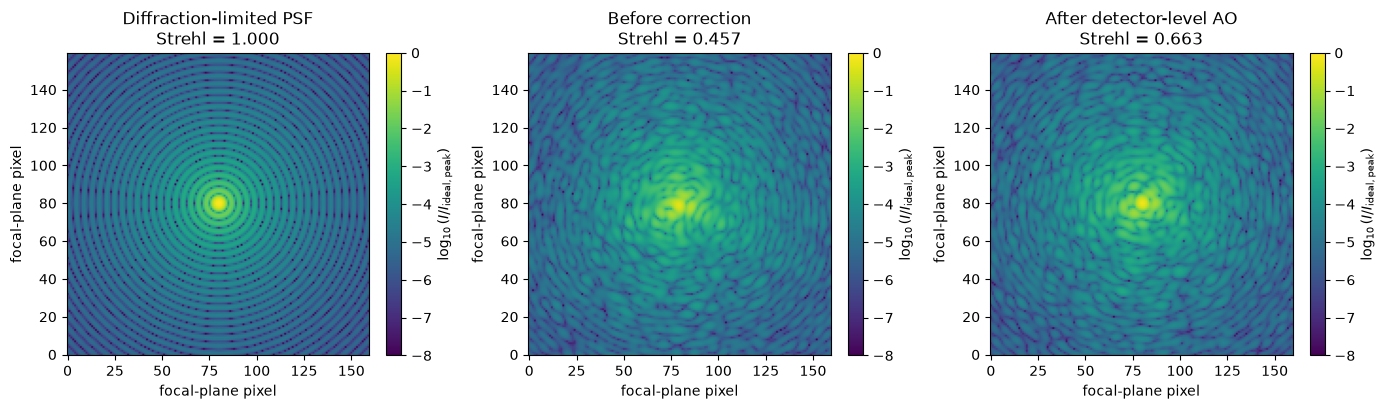

In [51]:
# ------------------------------------------------------------
# 2D log-scale PSF comparison
# normalized by diffraction-limited PSF peak
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

crop = 80
center = psf_before.shape[0] // 2
sl = slice(center - crop, center + crop)

psf_items = [
    (
        psf_ideal,
        "Diffraction-limited PSF\nStrehl = 1.000",
    ),
    (
        psf_before,
        f"Before correction\nStrehl = {strehl_before:.3f}",
    ),
    (
        psf_after_det,
        f"After detector-level AO\nStrehl = {strehl_after_det:.3f}",
    ),
]

for ax, (psf, title) in zip(axes, psf_items):
    psf_norm = psf / ideal_peak
    psf_log = np.log10(np.maximum(psf_norm, 1e-8))

    im = ax.imshow(
        psf_log[sl, sl],
        origin="lower",
        vmin=-8,
        vmax=0,
    )

    ax.set_title(title)
    ax.set_xlabel("focal-plane pixel")
    ax.set_ylabel("focal-plane pixel")
    plt.colorbar(im, ax=ax, fraction=0.046, label=r"$\log_{10}(I/I_{\rm ideal,peak})$")

plt.tight_layout()
plt.show()

In [52]:
from mpl_toolkits.mplot3d import Axes3D


def plot_psf_surface_3d(
    psf,
    title="PSF",
    crop=80,
    stride=2,
    log_scale=True,
):
    """
    Plot PSF as a 3D surface.

    Parameters
    ----------
    psf : ndarray
        Normalized PSF.
    title : str
        Plot title.
    crop : int
        Half-size of central crop.
    stride : int
        Downsampling stride for plotting.
    log_scale : bool
        If True, plot log10 normalized intensity.
        If False, plot linear normalized intensity.
    """
    center = psf.shape[0] // 2
    sl = slice(center - crop, center + crop)

    psf_crop = psf[sl, sl]
    psf_crop = psf_crop / np.max(psf_crop)

    if log_scale:
        Z = np.log10(psf_crop + 1e-8)
        zlabel = "log10 normalized intensity"
    else:
        Z = psf_crop
        zlabel = "normalized intensity"

    Z = Z[::stride, ::stride]

    ny, nx = Z.shape
    x = np.arange(nx)
    y = np.arange(ny)
    Xp, Yp = np.meshgrid(x, y)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(
        Xp,
        Yp,
        Z,
        linewidth=0,
        antialiased=True,
    )

    ax.set_title(title)
    ax.set_xlabel("focal-plane x [pixel]")
    ax.set_ylabel("focal-plane y [pixel]")
    ax.set_zlabel(zlabel)

    plt.tight_layout()
    plt.show()

In [53]:
def plot_three_psf_surfaces_3d_same_scale(
    psf_ideal,
    psf_before,
    psf_after,
    crop=70,
    stride=2,
    log_scale=True,
    after_label="After detector-level AO",
):
    """
    Plot ideal, before-correction, and after-correction PSFs
    using the same absolute normalization.

    All PSFs are normalized by the peak of the diffraction-limited PSF.
    This makes the Strehl-ratio difference visually meaningful.
    """
    reference_peak = np.max(psf_ideal)

    strehl_before_local = np.max(psf_before) / reference_peak
    strehl_after_local = np.max(psf_after) / reference_peak

    psfs = [
        psf_ideal / reference_peak,
        psf_before / reference_peak,
        psf_after / reference_peak,
    ]

    titles = [
        "Diffraction-limited PSF\nStrehl = 1.000",
        f"Before correction\nStrehl = {strehl_before_local:.3f}",
        f"{after_label}\nStrehl = {strehl_after_local:.3f}",
    ]

    fig = plt.figure(figsize=(18, 5))

    for i, (psf_norm, title) in enumerate(zip(psfs, titles), start=1):
        center = psf_norm.shape[0] // 2
        sl = slice(center - crop, center + crop)

        psf_crop = psf_norm[sl, sl]

        if log_scale:
            Z = np.log10(np.maximum(psf_crop, 1e-8))
            zlabel = r"$\log_{10}(I/I_{\rm ideal,peak})$"
            zlim = (-8, 0)
        else:
            Z = psf_crop
            zlabel = r"$I/I_{\rm ideal,peak}$"
            zlim = (0, 1)

        Z = Z[::stride, ::stride]

        ny, nx = Z.shape
        x = np.arange(nx)
        y = np.arange(ny)
        Xp, Yp = np.meshgrid(x, y)

        ax = fig.add_subplot(1, 3, i, projection="3d")

        ax.plot_surface(
            Xp,
            Yp,
            Z,
            linewidth=0,
            antialiased=True,
        )

        ax.set_title(title)
        ax.set_xlabel("x [pixel]")
        ax.set_ylabel("y [pixel]")
        ax.set_zlabel(zlabel)
        ax.set_zlim(*zlim)

    plt.tight_layout()
    plt.show()

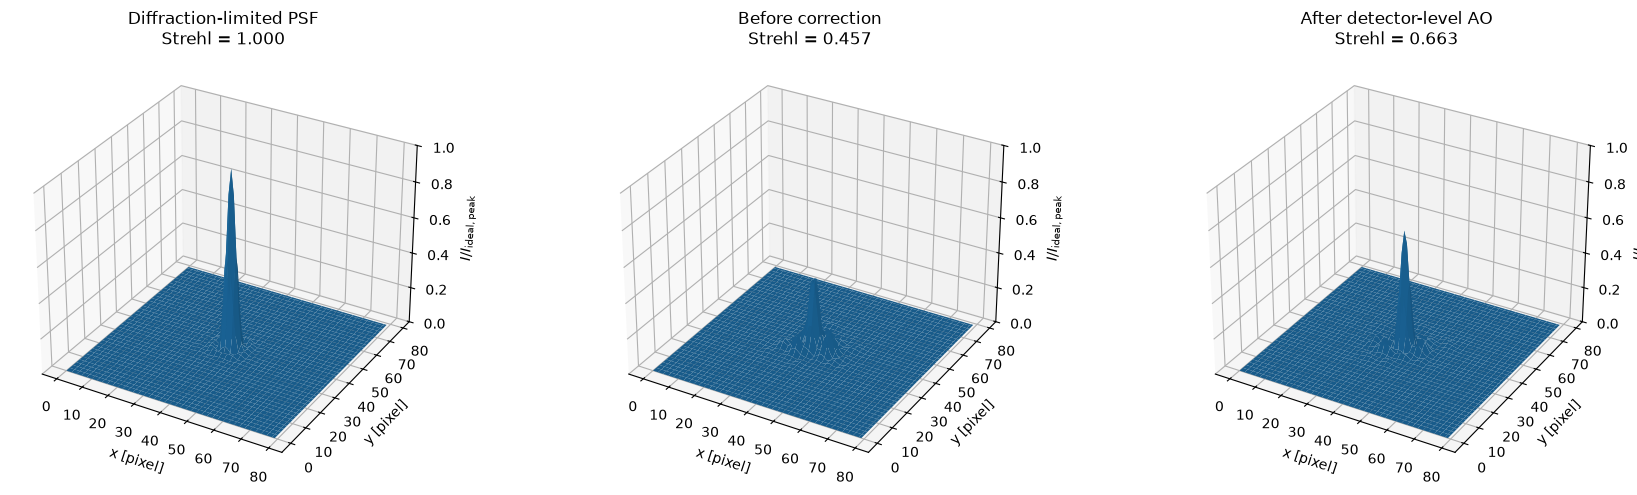

In [54]:
plot_three_psf_surfaces_3d_same_scale(
    psf_ideal,
    psf_before,
    psf_after_det,
    crop=40,
    stride=1,
    log_scale=False,
    after_label="After detector-level AO",
)

In [55]:
def radial_profile(psf, center=None):
    """
    Compute azimuthally averaged radial profile of a PSF.
    """
    ny, nx = psf.shape

    if center is None:
        center = (nx // 2, ny // 2)

    x = np.arange(nx)
    y = np.arange(ny)
    Xp, Yp = np.meshgrid(x, y)

    r = np.sqrt((Xp - center[0])**2 + (Yp - center[1])**2)
    r_int = r.astype(int)

    profile = np.bincount(
        r_int.ravel(),
        weights=psf.ravel(),
    ) / np.bincount(r_int.ravel())

    radius = np.arange(len(profile))

    return radius, profile

In [56]:
# ------------------------------------------------------------
# PSF and Strehl diagnostics
# ------------------------------------------------------------

required_psf_functions = ["compute_psf_from_phase", "strehl_ratio"]

for fn in required_psf_functions:
    if fn not in globals():
        raise RuntimeError(
            f"{fn} is not defined. Please check whether psf_tools.py was imported correctly."
        )

if "W_corr_det" not in globals():
    raise RuntimeError("W_corr_det is not defined. Please run Step 8 first.")

print("PSF tools are available.")

PSF tools are available.


In [57]:
# ------------------------------------------------------------
# Compute PSFs and Strehl ratios
# ------------------------------------------------------------

pad_factor_psf = 4

psf_ideal = compute_psf_from_phase(
    np.zeros_like(W_atm),
    mask,
    pad_factor=pad_factor_psf,
)

psf_before = compute_psf_from_phase(
    W_atm,
    mask,
    pad_factor=pad_factor_psf,
)

psf_after_det = compute_psf_from_phase(
    W_corr_det,
    mask,
    pad_factor=pad_factor_psf,
)

strehl_before = strehl_ratio(
    W_atm,
    mask,
    pad_factor=pad_factor_psf,
)

strehl_after_det = strehl_ratio(
    W_corr_det,
    mask,
    pad_factor=pad_factor_psf,
)

print("Detector-level PSF / Strehl")
print("---------------------------")
print(f"Input wavefront RMS:        {rms(W_atm, mask):.4e} rad")
print(f"Detector residual RMS:      {rms(W_corr_det, mask):.4e} rad")
print(f"Strehl before correction:   {strehl_before:.4f}")
print(f"Strehl after detector AO:   {strehl_after_det:.4f}")
print(f"Strehl improvement factor:  {strehl_after_det / strehl_before:.3f}")

# Optional geometric baseline
if "result_atm_geo" in globals() and result_atm_geo is not None:
    psf_after_geo = compute_psf_from_phase(
        W_corr_geo,
        mask,
        pad_factor=pad_factor_psf,
    )

    strehl_after_geo = strehl_ratio(
        W_corr_geo,
        mask,
        pad_factor=pad_factor_psf,
    )

    print()
    print("Geometric baseline")
    print("------------------")
    print(f"Geometric residual RMS:     {rms(W_corr_geo, mask):.4e} rad")
    print(f"Strehl after geometric AO:  {strehl_after_geo:.4f}")
else:
    psf_after_geo = None
    strehl_after_geo = None

Detector-level PSF / Strehl
---------------------------
Input wavefront RMS:        1.0012e+00 rad
Detector residual RMS:      6.3538e-01 rad
Strehl before correction:   0.4573
Strehl after detector AO:   0.6628
Strehl improvement factor:  1.449

Geometric baseline
------------------
Geometric residual RMS:     6.3833e-01 rad
Strehl after geometric AO:  0.6605


In [ ]:
# ------------------------------------------------------------
# Plot PSFs on linear scale
# normalized by ideal diffraction-limited PSF peak
# ------------------------------------------------------------

ideal_peak = np.nanmax(psf_ideal)

if psf_after_geo is not None:
    psf_items = [
        (psf_ideal, "Diffraction-limited PSF"),
        (psf_before, f"Before AO\nStrehl = {strehl_before:.3f}"),
        (psf_after_geo, f"After geometric AO\nStrehl = {strehl_after_geo:.3f}"),
        (psf_after_det, f"After detector AO\nStrehl = {strehl_after_det:.3f}"),
    ]
else:
    psf_items = [
        (psf_ideal, "Diffraction-limited PSF"),
        (psf_before, f"Before AO\nStrehl = {strehl_before:.3f}"),
        (psf_after_det, f"After detector AO\nStrehl = {strehl_after_det:.3f}"),
    ]

# ------------------------------------------------------------
# Display window
#
# The PSF array is pad_factor * N = 1024 pixels across, but one lambda/D is
# only psf_ideal.shape[0] / N = 4 pixels. Everything above 1e-3 of the peak
# fits inside a 31 x 31 pixel box for the diffraction-limited PSF and a
# 73 x 70 box before AO: under 0.2 % of the field. Drawn uncropped, every
# panel becomes the same dot on a black square and the comparison is lost.
#
# A +/-40 pixel box is 10 lambda/D and already holds 98 % of the encircled
# energy, so it shows the core, the first rings and the inner halo.
# ------------------------------------------------------------

lambda_over_D_px = psf_ideal.shape[0] / N
PSF_CROP_PX = 40

psf_center = psf_ideal.shape[0] // 2
psf_slice = slice(psf_center - PSF_CROP_PX, psf_center + PSF_CROP_PX)
psf_half_lam = PSF_CROP_PX / lambda_over_D_px
psf_extent = [-psf_half_lam, psf_half_lam, -psf_half_lam, psf_half_lam]

fig, axes = plt.subplots(1, len(psf_items), figsize=(4 * len(psf_items), 4))

if len(psf_items) == 1:
    axes = [axes]

# One shared 0..1 colour scale across all panels.
#
# Letting each panel autoscale would renormalize every PSF to its own peak,
# which erases precisely the difference the Strehl ratio measures. With a
# shared scale, a lower Strehl is visible as a fainter core.
for ax, (psf, title) in zip(axes, psf_items):
    im = ax.imshow(
        psf[psf_slice, psf_slice] / ideal_peak,
        origin="lower",
        interpolation="nearest",
        extent=psf_extent,
        vmin=0.0,
        vmax=1.0,
    )
    ax.set_title(title)
    ax.set_xlabel(r"focal-plane offset [$\lambda/D$]")
    ax.set_ylabel(r"focal-plane offset [$\lambda/D$]")
    plt.colorbar(im, ax=ax, fraction=0.046, label="intensity / ideal peak")

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Plot PSFs on logarithmic scale
# ------------------------------------------------------------

# Same crop and same shared scale as the linear version. The log stretch is
# what makes the rings and the scattered halo visible: on a linear scale
# everything below a few percent of the peak is indistinguishable from zero,
# and that faint structure is where the AO correction differs most.

fig, axes = plt.subplots(1, len(psf_items), figsize=(4 * len(psf_items), 4))

if len(psf_items) == 1:
    axes = [axes]

for ax, (psf, title) in zip(axes, psf_items):
    psf_norm = psf[psf_slice, psf_slice] / ideal_peak
    psf_log = np.log10(np.maximum(psf_norm, 1e-10))

    im = ax.imshow(
        psf_log,
        origin="lower",
        interpolation="nearest",
        extent=psf_extent,
        vmin=-6,
        vmax=0,
    )
    ax.set_title(title + "\nlog10 scale")
    ax.set_xlabel(r"focal-plane offset [$\lambda/D$]")
    ax.set_ylabel(r"focal-plane offset [$\lambda/D$]")
    plt.colorbar(im, ax=ax, fraction=0.046, label="log10 (intensity / ideal peak)")

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# PSF central cross-section
# ------------------------------------------------------------

# A 1D cut does not suffer the rendering collapse of the 2D panels, so it can
# show a wider field than the images above. It is still restricted, because
# the full array runs to +/-128 lambda/D and plotting all of it compresses the
# core and the first rings into a single vertical spike.

PSF_PROFILE_HALF_LAM = 25.0

plt.figure(figsize=(7, 4))

profile_items = [
    (psf_ideal, "diffraction-limited"),
    (psf_before, "before AO"),
    (psf_after_det, "after detector AO"),
]

if psf_after_geo is not None:
    profile_items.append((psf_after_geo, "after geometric AO"))

for psf, label in profile_items:
    center = psf.shape[0] // 2
    profile = psf[center, :] / ideal_peak
    x = (np.arange(len(profile)) - center) / lambda_over_D_px

    plt.semilogy(x, np.maximum(profile, 1e-12), label=label)

plt.xlim(-PSF_PROFILE_HALF_LAM, PSF_PROFILE_HALF_LAM)
plt.ylim(1e-7, 2.0)
plt.xlabel(r"focal-plane offset [$\lambda/D$]")
plt.ylabel("intensity / ideal peak")
plt.title("PSF central cross-section")
plt.grid(True, which="both")
plt.legend()
plt.show()

In [61]:
# ------------------------------------------------------------
# Compare measured Strehl with Maréchal approximation
# ------------------------------------------------------------

sigma_before = rms(W_atm, mask)
sigma_after_det = rms(W_corr_det, mask)

marechal_before = np.exp(-sigma_before**2)
marechal_after_det = np.exp(-sigma_after_det**2)

print("Maréchal approximation check")
print("---------------------------")
print(f"Before AO:")
print(f"  phase RMS:          {sigma_before:.4e} rad")
print(f"  measured Strehl:    {strehl_before:.4f}")
print(f"  exp(-sigma^2):      {marechal_before:.4f}")

print()
print(f"After detector AO:")
print(f"  phase RMS:          {sigma_after_det:.4e} rad")
print(f"  measured Strehl:    {strehl_after_det:.4f}")
print(f"  exp(-sigma^2):      {marechal_after_det:.4f}")

if strehl_after_geo is not None:
    sigma_after_geo = rms(W_corr_geo, mask)
    marechal_after_geo = np.exp(-sigma_after_geo**2)

    print()
    print(f"After geometric AO:")
    print(f"  phase RMS:          {sigma_after_geo:.4e} rad")
    print(f"  measured Strehl:    {strehl_after_geo:.4f}")
    print(f"  exp(-sigma^2):      {marechal_after_geo:.4f}")

Maréchal approximation check
---------------------------
Before AO:
  phase RMS:          1.0012e+00 rad
  measured Strehl:    0.4573
  exp(-sigma^2):      0.3670

After detector AO:
  phase RMS:          6.3538e-01 rad
  measured Strehl:    0.6628
  exp(-sigma^2):      0.6678

After geometric AO:
  phase RMS:          6.3833e-01 rad
  measured Strehl:    0.6605
  exp(-sigma^2):      0.6653


### PSF and Strehl after detector-level AO correction

This section converts the reconstructed residual wavefront into image-plane performance metrics.

The detector-level AO correction reduces the phase RMS of the incoming atmospheric wavefront. This leads to a sharper PSF core and a higher Strehl ratio. The comparison with the diffraction-limited PSF shows how close the corrected image is to the ideal telescope response.

The geometric SH-WFS reconstruction should be interpreted as an idealized upper-performance baseline. The detector-level reconstruction includes additional degradation from spot formation, detector sampling, photon noise, read noise, background noise, centroid bias, and response-matrix conditioning.

The Maréchal approximation, $$S \approx \exp(-\sigma_\phi^2)$$, provides a useful consistency check between residual phase RMS and Strehl ratio when the residual phase is not too large.

## Summary and interpretation

This notebook demonstrates an end-to-end geometric Shack-Hartmann wavefront sensing and modal reconstruction pipeline. A known low-order Zernike-like wavefront is first used as a sanity check. The reconstruction recovers the injected modal coefficients with negligible residual error, confirming that the slope measurement, response matrix construction, least-squares reconstruction, and wavefront synthesis are internally consistent.

The same pipeline is then applied to random atmospheric phase screens. Since the reconstruction basis contains only a limited set of low-order modes, the correction removes mainly the large-scale aberration components. The residual wavefront error remains significant because high-spatial-frequency atmospheric structures cannot be represented by the low-order modal basis. This demonstrates the role of modal truncation error in low-order AO correction.

The lenslet-number scan shows that increasing the number of Shack-Hartmann sub-apertures does not automatically lead to a monotonic decrease in residual RMS when the reconstructed modal basis is fixed. More lenslets provide finer slope sampling, but the correction is still limited by the number and type of reconstructed modes. A more complete sampling-versus-mode-order trade-off is studied in the later heatmap notebook.

The PSF and Strehl-ratio analysis connects the wavefront reconstruction to image quality. The simulated Strehl ratio improves after low-order correction, showing that the reduction in wavefront RMS also leads to a more concentrated focal-plane PSF.

Overall, this notebook serves as the baseline demonstration of the SH-WFS reconstruction pipeline. It validates the basic modal reconstruction method and motivates the later parameter studies on Zernike order, lenslet sampling, measurement noise, and regularization.